# Grounded Explanation Agent - LangGraph Demo

Runnable slice of the thesis architecture (Chapter 4, Figure 4.1: *Full graph
architecture of the proposed Agentic Multimodal RAG system*). The graph is built with
**dummy node functions** first so the wiring, the routing and both correction loops
can be verified before any real model is attached.

Scope for today:

| Node | Stage |
|---|---|
| `N1` | Query Intake - split the question into sub-goals |
| `N2` | Query Encoder - SPECTER2 query embedding + filters |
| `N3` / `N4` | Corpus Ingestion / Dual Index Build - offline, once per paper |
| `N5` | Agentic Planner - picks one retrieval tool per round |
| `N6a` / `N6b` / `N6c` | TextRetriever / TableRetriever / FigureRetriever (ColPali) |
| `N7` | Region Zoom - crop and re-encode a small figure |
| `N8` | Cross-Modal Linking - the evidence buffer |
| `N9` | Grounded Generator - answers from the buffer only |
| `N10a` / `N10b` / `N10c` | Claim links / Bounding boxes / DAG trace |
| `N11` / `N12` | Report synthesis / Final output |

Plus the two gates: **G1 Sufficiency Gate** (retrieval loop) and **G2 Faithfulness
Gate** (regenerate loop).

**Evidence note:** only the retrieval tools (N6a-N7) can bring evidence in, and N9 can
read nothing but the buffer N8 keeps. That separation is what turns G2 into an
equality test against one fixed source instead of a judgement call.

**Hardware note:** this notebook runs unmodified on all three machines - Intel Arc B580
(`xpu` backend), NVIDIA RTX 3070 (`cuda` backend) and the laptop (CPU). Nothing below
hardcodes a device.

## 0. Environment setup (run once per machine)

`torch` is installed *per machine* with a different wheel. It is deliberately **not** in
`requirements.txt`, or one of the three setups would break.

```bash
# Intel Arc B580 (Windows desktop)
pip install torch torchvision --index-url https://download.pytorch.org/whl/xpu

# NVIDIA RTX 3070 (university)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

# laptop (CPU only)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
```

Everything else is identical on all machines:

```bash
pip install -r requirements.txt
```

In [1]:
# Uncomment on a fresh machine. torch/torchvision are installed separately (see above).
# %pip install -q -r ../requirements.txt

## 1. Imports

In [2]:
import io
import json
import math
import operator
import random
import re
import sys
import time
import urllib.request
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from importlib.metadata import version
from pathlib import Path
from typing import Annotated, Any, Optional, TypedDict

import numpy as np
import torch

# Intel Arc (XPU) support lived in a separate extension on older torch builds.
# torch >= 2.5 ships torch.xpu natively, so this import is optional and must
# never be allowed to hard-fail on the NVIDIA machine or the laptop. A version
# mismatch shows up as OSError/RuntimeError rather than ImportError, hence the tuple.
try:
    import intel_extension_for_pytorch as ipex  # noqa: F401
    _HAS_IPEX = True
except (ImportError, OSError, RuntimeError):
    _HAS_IPEX = False

# langgraph
from langgraph.graph import END, START, StateGraph
from IPython.display import Markdown, display

print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}")
print(f"numpy       {np.__version__}")
print(f"langgraph   {version('langgraph')}")
print(f"pymupdf     {version('pymupdf')}")
print(f"ipex        {'yes' if _HAS_IPEX else 'not installed (fine: torch.xpu is built in)'}")

python      3.12.3
torch       2.14.0+cpu
numpy       2.5.3
langgraph   1.2.12
pymupdf     1.28.2
ipex        not installed (fine: torch.xpu is built in)


## 2. Device resolution — Arc B580 / RTX 3070 / CPU

No node in Sections 5-12 touches the device: every one of them is a stub. The device
matters from Day 3 of the plan, when ColQwen2 and SPECTER2 are loaded for real, and
these four helpers are what that code will call.

In [3]:
def get_device() -> torch.device:
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [4]:
def get_model_dtype(device: torch.device) -> torch.dtype:
    # dtype for ColQwen2 / SPECTER2 inference. Both GPUs run bf16 natively
    # (Arc: XMX engines, Ampere: tensor cores); the CPU stays in fp32.
    if device.type in ("xpu", "cuda"):
        return torch.bfloat16
    return torch.float32

In [5]:
def empty_cache(device: torch.device) -> None:
    if device.type == "xpu":
        torch.xpu.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

In [6]:
def describe_device(device: torch.device) -> str:
    if device.type == "xpu":
        return torch.xpu.get_device_name(0)
    if device.type == "cuda":
        return torch.cuda.get_device_name(0)
    return "CPU"

In [7]:
DEVICE = get_device()
MODEL_DTYPE = get_model_dtype(DEVICE)
print(f"device      {DEVICE}  ({describe_device(DEVICE)})")
print(f"model dtype {MODEL_DTYPE}")

device      cpu  (CPU)
model dtype torch.float32


## 3. Constants

The loop limits, the shapes of the two indexes, and the running example from the
thesis (Chapter 4, *Node-by-Node Specification*).

In [8]:
MODALITIES = ("text", "table", "figure")

MAX_ROUNDS   = 3              # bound on the retrieval loop   (G1 -> replan_prep -> N5)
MAX_REWRITES = 2              # bound on the regenerate loop  (G2 -> rewrite_prep -> N9)
TOP_K        = 1              # items each retriever returns per call
ZOOM_IF_AREA_BELOW = 0.30     # N7 runs when a figure covers less than 30% of its page

SPECTER2_DIM = 768            # SPECTER2 embedding width (text index)
COLPALI_DIM  = 128            # ColQwen2 multi-vector width (page index)
PATCH_GRID   = (32, 32)       # ColQwen2 patch grid per page image (rows, cols)
PAGE_W, PAGE_H = 595.0, 842.0 # A4 page, in PDF points

# The running example of the thesis: needs a text claim AND a table.
QUERY = ("Does the reported accuracy gain in Section 4 hold for the low-resource subset, "
         "and which table reports it?")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

print(f"modalities   {MODALITIES}")
print(f"loops        rounds<={MAX_ROUNDS}  rewrites<={MAX_REWRITES}")
print(f"indexes      text ({SPECTER2_DIM},)  page {PATCH_GRID[0] * PATCH_GRID[1]} patches x ({COLPALI_DIM},)")
print(f"root         {PROJECT_ROOT}")

modalities   ('text', 'table', 'figure')
loops        rounds<=3  rewrites<=2
indexes      text (768,)  page 1024 patches x (128,)
root         /home/tamim/Phitron


## 4. The graph State

Every query-time node reads from and writes into one shared `TypedDict`. A node
returns a **partial** dict containing only the keys it changed; LangGraph merges that
into the running state.

How a key is merged depends on whether it is annotated with a **reducer**:

| Kind | Merge behaviour | Used for |
|---|---|---|
| plain key | last write wins (overwrite) | fields exactly one node writes: `evidence` (only N8), `claims` (only N9, and `drop_unsupported` marking them), `faith_failures` (only G2) |
| `Annotated[list, operator.add]` | concatenate | `events`, which every node appends to, including the three proof nodes that run in parallel |

The evidence buffer is a plain key **on purpose**. The thesis rule is that only N8 may
add evidence, so exactly one node writes it; Section 10 checks that rule on real runs.

In [9]:
class AgentState(TypedDict, total=False):
    # Shared state for the grounded-explanation graph (thesis Chapter 4).
    #
    # total=False because nodes contribute keys progressively -- at START only the
    # question and the paper id exist, and asserting otherwise would make every
    # node responsible for fields it knows nothing about.

    # inputs
    question: str
    paper_id: str

    # N1/N2: understanding the question
    sub_goals:       list            # N1 -> [{"text": ..., "modality": "text"|"table"|"figure"}]
    query_filters:   dict            # N2 -> {"refs": {"section": "4"}, "entities": ["low-resource"]}
    query_embedding: Any             # N2 -> SPECTER2 query vector (768,)

    # N5-N7: planning and retrieval
    action:       dict               # N5 -> {"tool", "query", "sub_goal", "planner"}
    tried:        list               # N5 -> (sub_goal, tool) pairs already used
    new_evidence: list               # N6a-N7 -> found this round, not yet in the buffer

    # N8: the evidence buffer -- the ONLY thing N9 can read
    evidence: list                   # plain key: N8 is its only writer
    links:    list                   # N8 -> [(id_a, id_b, reason)]

    # control
    round:         int               # retrieval round, owned by replan_prep
    rewrite_count: int               # regenerate loop counter, owned by rewrite_prep
    status:        str               # ok | insufficient_evidence | unsupported_claims_dropped
    sufficiency:   dict              # G1 -> {"sufficient", "uncovered", "missing"}

    # N9 / G2
    claims:         list             # N9 -> [{"text", "cites": [...]}], replaced every draft
    drafts:         int              # N9 -> drafts written so far
    # plain list, NOT a reducer: only G2 writes it, and with operator.add the
    # failures of an earlier draft would survive a successful rewrite.
    faith_failures: list

    # N10a-N12: the three proofs and the output
    claim_links: list                # N10a
    boxes:       list                # N10b
    dag_trace:   dict                # N10c
    report:      str                 # N11
    answer:      str                 # N12

    # every node appends one entry; N10a-N10c write in the same step -> reducer
    events: Annotated[list, operator.add]

In [10]:
def new_state(question: str, paper_id: str = "demo-2026-001") -> AgentState:
    # Build a valid initial state. Collections start empty rather than absent, and
    # the round counter starts at 1: the first retrieval round needs no permission.
    return {
        "question": question,
        "paper_id": paper_id,
        "round": 1,
        "rewrite_count": 0,
        "drafts": 0,
        "status": "ok",
        "tried": [],
        "new_evidence": [],
        "evidence": [],
        "links": [],
        "claims": [],
        "faith_failures": [],
        "events": [],
    }

In [11]:
def describe_state(state: dict, title: str = "STATE") -> None:
    # Compact state dump -- long lists and records are summarised, not printed.
    print(f"--- {title} " + "-" * max(0, 56 - len(title)))
    for k, v in state.items():
        if isinstance(v, (list, tuple)):
            shown = f"[{len(v)} item(s)]"
        elif isinstance(v, dict):
            shown = "{" + ", ".join(list(v)[:4]) + ("..." if len(v) > 4 else "") + "}"
        elif isinstance(v, str) and len(v) > 48:
            shown = v[:45] + "..."
        else:
            shown = v
        print(f"  {k:16s} {shown}")

In [12]:
print("AgentState fields:", len(AgentState.__annotations__))
describe_state(new_state(QUERY), "INITIAL")

AgentState fields: 23
--- INITIAL -------------------------------------------------
  question         Does the reported accuracy gain in Section 4 ...
  paper_id         demo-2026-001
  round            1
  rewrite_count    0
  drafts           0
  status           ok
  tried            [0 item(s)]
  new_evidence     [0 item(s)]
  evidence         [0 item(s)]
  links            [0 item(s)]
  claims           [0 item(s)]
  faith_failures   [0 item(s)]
  events           [0 item(s)]


## 5. The paper and the offline path (N3 → N4)

Retrieval needs something to search, so the first graph is the **offline** one: N3
turns a paper into records, N4 builds the two indexes. In the full system it runs once
per corpus, before any question arrives.

### The fake paper is laid out, not invented

`FAKE_PAPER` is two pages: section text, one table (Table 3) and one figure (Figure 2).
Every record carries its page and its box in PDF points - the same coordinates the
real N3 reads with PyMuPDF. They were **measured** by laying the text out with
PyMuPDF, and Section 13 renders a real PDF from exactly these records, so every box the
graph returns can be checked against the page.

The numbers are consistent, not typed to match. The test subsets are 80% high-resource
and 20% low-resource, so the *All* row of Table 3 is the weighted average of the other
two, and the Results paragraph quotes that row's gain (+3.9). Test B below recomputes
it.

### Stubs carry shapes, not data

`FakeTensor` stands in for a torch tensor: it carries the real shape - `(768,)` out of
SPECTER2, `(1024, 128)` patches per page out of ColQwen2 - and no data. Nothing here
allocates a tensor or touches the GPU, but a shape mismatch between nodes shows up now
rather than on the day the real models are plugged in.

In [13]:
@dataclass(frozen=True)
class FakeTensor:
    # Stand-in for a torch tensor: carries the real shape, no data.
    shape: tuple
    note:  str = ""

    def __repr__(self) -> str:
        return f"<FakeTensor {self.shape} {self.note}>"

In [14]:
TRACE = True


def trace(node: str, msg: str) -> None:
    if TRACE:
        print(f"  [{node:5s}] {msg}")


def step(node: str, msg: str, short: str = None) -> list:
    # Print a trace line and return it as an `events` entry. Every query-time node
    # ends with "events": step(...). The printed line is for the reader; the entry
    # is what N10c turns into the DAG trace, and `short` is its label in the path.
    trace(node, msg)
    return [{"node": node, "msg": msg, "short": short}]

In [15]:
# The paper the demo searches. Boxes are (x_min, y_min, x_max, y_max) in PDF points
# on an A4 page, measured with PyMuPDF (see the notes above).
FAKE_PAPER = {
    "paper_id": "demo-2026-001",
    "pages": 2,
    "front": [
        {"page": 1, "size": 16, "font": "hebo", "bbox": (60.0, 56.0, 535.0, 84.9),
         "text": "Cross-Lingual Transfer for Multilingual Sentiment Analysis"},
        {"page": 1, "size": 9, "font": "heit", "bbox": (60.0, 88.9, 535.0, 105.6),
         "text": "Synthetic two-page excerpt generated for this demo. Not a real publication."},
    ],
    "headings": [
        {"page": 1, "section": "1", "text": "1   Introduction",   "bbox": (60.0, 119.6, 535.0, 141.8)},
        {"page": 1, "section": "2", "text": "2   Method",         "bbox": (60.0, 188.3, 535.0, 210.5)},
        {"page": 1, "section": "3", "text": "3   Training Setup", "bbox": (60.0, 257.0, 535.0, 279.2)},
        {"page": 2, "section": "4", "text": "4   Results",        "bbox": (60.0, 56.0, 535.0, 78.2)},
        {"page": 2, "section": "5", "text": "5   Conclusion",     "bbox": (60.0, 254.3, 535.0, 276.5)},
    ],
    "chunks": [
        {"id": "c1", "page": 1, "section": "1", "bbox": (60.0, 143.8, 535.0, 176.3),
         "text": "Sentiment classifiers work well for languages with large labelled datasets, "
                 "but many languages have little or no labelled data. We study how far "
                 "cross-lingual transfer from English can close this gap."},
        {"id": "c2", "page": 1, "section": "2", "bbox": (60.0, 212.5, 535.0, 245.0),
         "text": "We fine-tune a multilingual encoder on English product reviews and apply it "
                 "to twelve other languages without any target-language labels."},
        {"id": "c3", "page": 1, "section": "3", "bbox": (60.0, 281.2, 535.0, 313.7),
         "text": "We train for 20 epochs with early stopping on the validation set. "
                 "Figure 2 shows the validation loss after each epoch."},
        {"id": "c4", "page": 2, "section": "4", "bbox": (60.0, 80.2, 535.0, 126.4),
         "text": "Table 3 compares our model with the baseline on each test subset. Averaged "
                 "over all test data, our model achieves an accuracy gain of 3.9 points over "
                 "the baseline. Most of this gain comes from high-resource languages, where "
                 "training data is plentiful."},
        {"id": "c5", "page": 2, "section": "5", "bbox": (60.0, 278.5, 535.0, 311.0),
         "text": "Cross-lingual transfer improves accuracy overall, but the benefit is uneven "
                 "across languages. Narrowing the remaining gap for languages with little "
                 "training data is left to future work."},
    ],
    "tables": [
        {"id": "t3", "label": "Table 3", "page": 2, "bbox": (122.5, 134.4, 472.5, 214.4),
         "col_widths": (120.0, 80.0, 80.0, 70.0), "row_h": 20.0,
         "caption": "Table 3: Accuracy (%) of the baseline and our model on each test subset.",
         "caption_bbox": (60.0, 222.4, 535.0, 240.3),
         "header": ["Subset", "Baseline", "Ours", "Gain"],
         "rows": [["High-resource", "88.1", "92.5", "+4.4"],
                  ["Low-resource",  "71.3", "73.0", "+1.7"],
                  ["All",           "84.7", "88.6", "+3.9"]]},
    ],
    "figures": [
        {"id": "f2", "label": "Figure 2", "page": 1, "bbox": (150.0, 321.7, 445.0, 521.7),
         "caption": "Figure 2: Validation loss per training epoch. The loss drops quickly "
                    "and plateaus after epoch 10.",
         "caption_bbox": (60.0, 527.7, 535.0, 545.6),
         "epochs": list(range(1, 21))},
    ],
    # share of test examples per subset -- what makes the All row an average
    "subset_weights": {"High-resource": 0.8, "Low-resource": 0.2},
}
PAPERS = {FAKE_PAPER["paper_id"]: FAKE_PAPER}      # the corpus: one paper for the demo
print(f"{FAKE_PAPER['paper_id']}: {len(FAKE_PAPER['chunks'])} chunks, "
      f"{len(FAKE_PAPER['tables'])} table, {len(FAKE_PAPER['figures'])} figure")

demo-2026-001: 5 chunks, 1 table, 1 figure


In [16]:
def grid_boxes(table: dict) -> list:
    # Page coordinates of every cell, row by row, header row first.
    # Real version: the Table Transformer returns these boxes. Here they follow from
    # the table's ruled grid -- column widths and row height -- which is exactly how
    # the table is drawn in Section 13.
    x0, y0 = table["bbox"][:2]
    xs = [x0]
    for w in table["col_widths"]:
        xs.append(xs[-1] + w)
    n_rows = 1 + len(table["rows"])
    return [[(xs[c], y0 + r * table["row_h"], xs[c + 1], y0 + (r + 1) * table["row_h"])
             for c in range(len(xs) - 1)]
            for r in range(n_rows)]


STOPWORDS = set('''a an and are as at be by did do does for from has have how in is it its
many much of on or our over than that the their this to was we were what when which who
why with'''.split())


def terms(text: str) -> list:
    # Lower-case content words and numbers; "low-resource" and "3.9" stay whole.
    return [t for t in re.findall(r"[a-z0-9]+(?:[-.][a-z0-9]+)*", text.lower())
            if t not in STOPWORDS]


def sentences(text: str) -> list:
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]


def table_text(table: dict) -> str:
    # A table as the text the generator reads: caption, header, one line per row.
    lines = [table["caption"], " | ".join(table["header"])]
    lines += [" | ".join(row) for row in table["rows"]]
    return "\n".join(lines)

In [17]:
class IngestState(TypedDict, total=False):
    # State of the offline graph. Runs once per paper, before any question.
    paper_id:   str
    pages:      list      # N3 -> one record per rendered page
    chunks:     list      # N3 -> narrative text with section, page and bbox
    tables:     list      # N3 -> tables with header, rows and a box per cell
    figures:    list      # N3 -> figures with caption and bbox
    text_index: dict      # N4 -> SPECTER2 vectors (+ the keyword stand-in)
    page_index: dict      # N4 -> ColQwen2 patch embeddings per page

In [18]:
def n3_corpus_ingestion(state: IngestState) -> dict:
    # N3 -- Corpus Ingestion. Every page becomes an image; its text, tables and
    # figures become records that keep their page coordinates.
    #
    # Real version: PyMuPDF renders each page at 150 dpi and extracts the text
    # blocks with their boxes; the Table Transformer recovers each table's grid.
    paper = PAPERS.get(state.get("paper_id"))
    assert paper, f"N3: unknown paper {state.get('paper_id')!r}"
    pages = [{"page": p, "size": (PAGE_W, PAGE_H),
              "image": FakeTensor((1754, 1240, 3), "150 dpi render")}
             for p in range(1, paper["pages"] + 1)]
    tables = [{**t, "cell_boxes": grid_boxes(t)} for t in paper["tables"]]
    trace("N3", f"{len(pages)} pages -> {len(paper['chunks'])} chunks, "
                f"{len(tables)} table(s), {len(paper['figures'])} figure(s)")
    return {"pages": pages, "chunks": paper["chunks"], "tables": tables,
            "figures": paper["figures"]}

In [19]:
def n4_dual_index_build(state: IngestState) -> dict:
    # N4 -- Dual Index Build: one index over the text, one over the page images.
    #
    # Real version: SPECTER2 (proximity adapter) embeds every chunk and caption
    # into FAISS; ColQwen2 embeds every page image as PATCH_GRID patches of
    # COLPALI_DIM. The stub keeps those shapes, and an IDF table over the same
    # texts stands in for similarity, so retrieval is deterministic.
    chunks, tables, figures, pages = (state.get(k) for k in ("chunks", "tables", "figures", "pages"))
    assert chunks and pages, "N4: N3 did not run (no chunks or pages in state)"
    docs = ([c["text"] for c in chunks] + [table_text(t) for t in tables]
            + [f["caption"] for f in figures])
    df = Counter(t for d in docs for t in set(terms(d)))
    idf = {t: math.log(1 + len(docs) / (1 + n)) for t, n in df.items()}
    n_patches = PATCH_GRID[0] * PATCH_GRID[1]
    text_index = {"vectors": FakeTensor((len(docs), SPECTER2_DIM), "SPECTER2"), "idf": idf}
    page_index = {"patches": FakeTensor((len(pages), n_patches, COLPALI_DIM), "ColQwen2"),
                  "grid": PATCH_GRID}
    trace("N4", f"text index {text_index['vectors'].shape}, page index {page_index['patches'].shape}")
    return {"text_index": text_index, "page_index": page_index}

In [20]:
def build_ingest_graph():
    # The offline path: N3 -> N4. Runs once per corpus, before any question.
    g = StateGraph(IngestState)
    g.add_node("n3_corpus_ingestion", n3_corpus_ingestion)
    g.add_node("n4_dual_index_build", n4_dual_index_build)
    g.add_edge(START, "n3_corpus_ingestion")
    g.add_edge("n3_corpus_ingestion", "n4_dual_index_build")
    g.add_edge("n4_dual_index_build", END)
    return g.compile()

In [21]:
# A: build the indexes once; every retriever below searches CORPUS
ingest_graph = build_ingest_graph()
print("invoking:")
CORPUS = ingest_graph.invoke({"paper_id": FAKE_PAPER["paper_id"]})
print()
t3 = CORPUS["tables"][0]
print(f"text index : {CORPUS['text_index']['vectors']}")
print(f"page index : {CORPUS['page_index']['patches']}")
print(f"table cells: {len(t3['cell_boxes'])} rows x {len(t3['cell_boxes'][0])} columns; "
      f"'Low-resource / Gain' is at {t3['cell_boxes'][2][3]}")


def on_page(box: tuple) -> bool:
    return 0 <= box[0] < box[2] <= PAGE_W and 0 <= box[1] < box[3] <= PAGE_H


records = CORPUS["chunks"] + CORPUS["tables"] + CORPUS["figures"]
assert all(on_page(r["bbox"]) for r in records), "a record lies off the page"
assert all(on_page(b) for row in t3["cell_boxes"] for b in row), "a cell lies off the page"
assert CORPUS["page_index"]["patches"].shape == (2, PATCH_GRID[0] * PATCH_GRID[1], COLPALI_DIM)
print("PASS: both indexes built; every record and every table cell has a box on its page")

invoking:
  [N3   ] 2 pages -> 5 chunks, 1 table(s), 1 figure(s)
  [N4   ] text index (7, 768), page index (2, 1024, 128)

text index : <FakeTensor (7, 768) SPECTER2>
page index : <FakeTensor (2, 1024, 128) ColQwen2>
table cells: 4 rows x 4 columns; 'Low-resource / Gain' is at (402.5, 174.4, 472.5, 194.4)
PASS: both indexes built; every record and every table cell has a box on its page


In [22]:
# B: the numbers are aggregated, not invented
rows = {r[0]: [float(v) for v in r[1:]] for r in t3["rows"]}
weights = FAKE_PAPER["subset_weights"]
for col, name in enumerate(["Baseline", "Ours"]):
    average = sum(w * rows[subset][col] for subset, w in weights.items())
    print(f"  All/{name:8s} = 0.8 x {rows['High-resource'][col]} + 0.2 x {rows['Low-resource'][col]}"
          f" = {average:.2f} -> table says {rows['All'][col]}")
    assert round(average, 1) == rows["All"][col], f"All/{name} is not the weighted average"

assert round(rows["All"][1] - rows["All"][0], 1) == rows["All"][2] == 3.9
assert "gain of 3.9 points" in CORPUS["chunks"][3]["text"]
print("OK: the All row is the weighted average, and the Results paragraph quotes its +3.9")

  All/Baseline = 0.8 x 88.1 + 0.2 x 71.3 = 84.74 -> table says 84.7
  All/Ours     = 0.8 x 92.5 + 0.2 x 73.0 = 88.60 -> table says 88.6
OK: the All row is the weighted average, and the Results paragraph quotes its +3.9


## 6. The query path (N1 → N2 → N5 → N6a → N8)

Five dummy nodes and the first query graph that actually executes: one text retrieval,
in a straight line, into the buffer.

Every node has the signature the real implementation will keep:

```python
def nX_something(state: AgentState) -> dict:
    ...
    return {"only": "the", "keys": "it changed"}
```

Later, making a node real means replacing its **body**. The signature, the node name
and the edges never change - that is the whole reason for building the graph with
stubs first.

Three conventions worth noting:

* **`Evidence` is the one shared format of N8.** Every retrieval tool returns it:
  `content` is what the generator reads, `bbox` and `cells` are what N10a/N10b need to
  point at the page later.
* **Similarity is a keyword stand-in.** `score()` is IDF-weighted word overlap, in place
  of SPECTER2 cosine similarity and ColQwen2 MaxSim. Deterministic, so every run
  retrieves the same items.
* **Each node asserts its input exists.** A wiring mistake then fails loudly at the
  offending node instead of quietly propagating `None` three nodes downstream.

In [23]:
@dataclass
class Evidence:
    # One item in the evidence buffer -- the single shared format of N8.
    kind:    str                   # "text" | "table" | "figure"
    source:  str                   # record id in the corpus: "c4", "t3", "f2"
    page:    int
    content: str                   # what the generator reads
    bbox:    tuple                 # (x_min, y_min, x_max, y_max), PDF points
    tool:    str                   # which tool produced it
    score:   float = 0.0
    query:   str = ""              # what it was retrieved for
    label:   str = ""              # "Table 3", "Figure 2"; empty for text
    section: Optional[str] = None
    id:      str = ""              # "E1", "E2", ... assigned by N8
    round:   int = 0               # retrieval round that found it
    cells:      list = field(default_factory=list, repr=False)   # tables: every cell + bbox
    similarity: Any = field(default=None, repr=False)            # figures: patch map (N6c)
    crop:       Any = field(default=None, repr=False)            # zoomed view (N7)

    @property
    def key(self) -> tuple:
        # Two items with the same key are the same evidence.
        return (self.kind, self.source, self.tool)


def score(query: str, text: str) -> float:
    # Keyword stand-in for embedding similarity: IDF-weighted word overlap.
    idf = CORPUS["text_index"]["idf"]
    return round(sum(idf.get(t, 0.0) for t in set(terms(query)) & set(terms(text))), 2)


def describe_found(found: list) -> str:
    if not found:
        return "found nothing"
    return "; ".join(f"{e.source} (page {e.page}, score {e.score}): "
                     f"\"{e.content.splitlines()[0][:48]}...\"" for e in found)

In [24]:
#N1
def n1_query_intake(state: AgentState) -> dict:
    # N1 -- Query Intake. Break the question into sub-goals, each needing one kind
    # of evidence.
    #
    # Real version: one call to the vision-language model, asked for JSON. The
    # stand-in splits on ", and" / ";" and reads the modality off keywords.
    q = state.get("question")
    assert q, "N1: no question in state"
    parts = [p.strip(" ?.") for p in re.split(r";\s*(?:and\s+)?|,\s*and\s+", q) if p.strip(" ?.")]
    goals = []
    for text in parts:
        modality = ("table" if re.search(r"\btables?\b", text, re.I)
                    else "figure" if re.search(r"\b(figures?|plots?|charts?|curves?)\b", text, re.I)
                    else "text")
        goals.append({"text": text[0].upper() + text[1:], "modality": modality})
    listing = "; ".join(f"({i}) {g['modality']}: {g['text']}" for i, g in enumerate(goals, 1))
    return {"sub_goals": goals, "events": step("N1", f"{len(goals)} sub-goal(s): {listing}")}

In [25]:
#N2
def n2_query_encoder(state: AgentState) -> dict:
    # N2 -- Query Encoder. Embed the question and pull out the filters every
    # retrieval afterwards depends on: references (Section / Table / Figure N) and
    # names the evidence must mention (a subset, a language).
    #
    # Real version: SPECTER2 query embedding (adhoc_query adapter) plus the
    # vision-language model for the filters. The stand-in uses regular expressions.
    q = state.get("question")
    assert q, "N2: no question in state"
    refs = {kind.lower(): num for kind, num in re.findall(r"\b(Section|Table|Figure)\s+(\d+)", q)}
    entities = re.findall(r"([\w-]+)\s+subset", q)
    words = re.findall(r"[A-Za-z][\w-]*", q)
    entities += [w for w in words[1:]
                 if w[0].isupper() and w.lower() not in ("section", "table", "figure")]
    emb = FakeTensor((SPECTER2_DIM,), "SPECTER2 query")
    return {"query_filters": {"refs": refs, "entities": entities}, "query_embedding": emb,
            "events": step("N2", f"query -> {emb.shape}, refs={refs}, must mention={entities}")}

In [26]:
# Which planner proposes the next tool: "rules" (the stand-in below) or "llm" (a
# local model, Section 14). Everything before Section 14 uses "rules", so none of
# those results depends on a language model.
PLANNER_MODE = "rules"


def rule_based_action(state: AgentState) -> dict:
    # The planner's stand-in logic: work on the first sub-goal G1 reported as
    # uncovered, with the tool for its modality; if that tool was already tried for
    # this sub-goal, move on to the next modality.
    goals, verdict = state["sub_goals"], state.get("sufficiency")
    uncovered = verdict["uncovered"] if verdict else list(range(len(goals)))
    target = uncovered[0] if uncovered else 0
    goal = goals[target]
    order = [goal["modality"]] + [m for m in MODALITIES if m != goal["modality"]]
    tool = next((m for m in order if (target, m) not in state.get("tried", [])), goal["modality"])
    extra = [e for e in state["query_filters"]["entities"] if e.lower() not in goal["text"].lower()]
    return {"tool": tool, "query": " ".join([goal["text"], *extra]), "sub_goal": target,
            "reason": f"sub-goal {target + 1} needs {goal['modality']} evidence"}

In [27]:
def propose_action(state: AgentState) -> dict:
    # Stage 1 of N5: which tool to call next, before any rule is applied.
    #
    # PLANNER_MODE "rules": rule_based_action. PLANNER_MODE "llm": the local model
    # (llm_plan, Section 14). If the model cannot be reached or replies badly, the
    # rules are used instead and the run records that it happened.
    assert PLANNER_MODE in ("rules", "llm"), f"unknown PLANNER_MODE {PLANNER_MODE!r}"
    rules = rule_based_action(state)
    if PLANNER_MODE == "llm":
        try:
            return {**rules, **llm_plan(state), "planner": "llm"}
        except (OSError, ValueError, KeyError) as e:        # unreachable, or a bad reply
            trace("N5", f"LLM planner failed ({type(e).__name__}) -> rules")
            return {**rules, "planner": "rules (LLM unavailable)"}
    return {**rules, "planner": "rules"}

In [28]:
#N5
def n5_agentic_planner(state: AgentState) -> dict:
    # N5 -- Agentic Planner. The only node that decides what happens next: it picks
    # ONE retrieval tool per round, and never adds evidence itself.
    #
    # Two stages, kept apart on purpose: propose_action says which tool, then the
    # rules here decide -- the tool must exist, and a (sub-goal, tool) pair that
    # already ran is not repeated. The rules hold whoever proposed.
    assert state.get("sub_goals"), "N5: N1 has not run (no sub_goals in state)"
    assert state.get("query_filters") is not None, "N5: N2 has not run (no query_filters in state)"
    action = propose_action(state)
    if action["tool"] not in MODALITIES or (action["sub_goal"], action["tool"]) in state["tried"]:
        action = {**rule_based_action(state), "planner": action["planner"] + ", overruled by rules"}
    missing = (state.get("sufficiency") or {}).get("missing")
    msg = (f"round {state['round']}: {action['tool']} <- \"{action['query']}\""
           + (f"  [G1: missing {missing}]" if missing else ""))
    return {"action": action, "tried": state["tried"] + [(action["sub_goal"], action["tool"])],
            "events": step("N5", msg)}

In [29]:
def text_retriever(query: str, section: Optional[str] = None, k: int = TOP_K) -> list:
    # Rank narrative chunks against the query, inside one section if N2 found one.
    pool = [c for c in CORPUS["chunks"] if c["section"] == section] or CORPUS["chunks"]
    ranked = sorted(pool, key=lambda c: -score(query, c["text"]))
    return [Evidence("text", c["id"], c["page"], c["text"], c["bbox"], "TextRetriever",
                     score(query, c["text"]), query=query, section=c["section"])
            for c in ranked[:k] if score(query, c["text"]) > 0]


#N6a
def n6a_text_retriever(state: AgentState) -> dict:
    # N6a -- TextRetriever: narrative chunks from the text index.
    # Real version: SPECTER2 query vector against the FAISS index built by N4.
    action = state.get("action")
    assert action and action["tool"] == "text", "N6a: the planner did not ask for text"
    found = text_retriever(action["query"], section=state["query_filters"]["refs"].get("section"))
    return {"new_evidence": found,
            "events": step("N6a", describe_found(found), short="TextRetriever")}

In [30]:
def link_evidence(buffer: list) -> list:
    # Cross-modal links: same page, text that cites "Table N" / "Figure N", zoomed views.
    links = []
    for i, a in enumerate(buffer):
        for b in buffer[i + 1:]:
            why = ["same page"] if a.page == b.page else []
            for x, y in ((a, b), (b, a)):
                if x.kind == "text" and y.label and y.label in x.content:
                    why.append(f"text cites {y.label}")
            if a.source == b.source and "RegionZoom" in (a.tool, b.tool):
                why.append("zoomed view")
            if why:
                links.append((a.id, b.id, ", ".join(why)))
    return links


#N8
def n8_evidence_buffer(state: AgentState) -> dict:
    # N8 -- Cross-Modal Linking. The only way evidence reaches the generator.
    #
    # Gives every new item an id, adds it to the buffer (skipping anything already
    # there) and links related items. Nothing after this node looks at the corpus.
    new = state.get("new_evidence")
    assert new is not None, "N8: no retrieval tool ran (no new_evidence in state)"
    buffer = list(state.get("evidence", []))
    seen = {e.key for e in buffer}
    added = []
    for ev in new:
        if ev.key in seen:
            continue
        ev.id, ev.round = f"E{len(buffer) + 1}", state["round"]
        buffer.append(ev)
        seen.add(ev.key)
        added.append(ev)
    links = link_evidence(buffer)
    msg = ("added " + ", ".join(f"{e.id}={e.kind}/{e.source}" for e in added)) if added else "nothing new"
    msg += f"; buffer holds {len(buffer)} item(s)"
    if links:
        msg += "; links " + ", ".join(f"{a}-{b}" for a, b, _ in links)
    return {"evidence": buffer, "links": links, "new_evidence": [], "events": step("N8", msg)}

In [31]:
print("defined: n1_query_intake, n2_query_encoder, n5_agentic_planner, n6a_text_retriever, n8_evidence_buffer")

defined: n1_query_intake, n2_query_encoder, n5_agentic_planner, n6a_text_retriever, n8_evidence_buffer


### Wiring and running it

```
START -> n1_query_intake -> n2_query_encoder -> n5_agentic_planner
      -> n6a_text_retriever -> n8_evidence_buffer -> END
```

Straight line, no branching yet.

`add_node(name, fn)` registers a node; `add_edge(a, b)` says b runs after a. A node is
registered under **the same name as the function that implements it**, so a box in
`show_graph()` can be found in this notebook by searching for its label.

`compile()` validates the graph - every node reachable, no dangling edges - and returns
something invokable. This is the first point where a wiring mistake becomes an error
rather than an opinion.

In [32]:
def build_query_graph():
    # Step 1 graph: the query path, linear -- one text retrieval into the buffer.
    g = StateGraph(AgentState)

    g.add_node("n1_query_intake",    n1_query_intake)
    g.add_node("n2_query_encoder",   n2_query_encoder)
    g.add_node("n5_agentic_planner", n5_agentic_planner)
    g.add_node("n6a_text_retriever", n6a_text_retriever)
    g.add_node("n8_evidence_buffer", n8_evidence_buffer)

    g.add_edge(START, "n1_query_intake")
    g.add_edge("n1_query_intake",    "n2_query_encoder")
    g.add_edge("n2_query_encoder",   "n5_agentic_planner")
    g.add_edge("n5_agentic_planner", "n6a_text_retriever")
    g.add_edge("n6a_text_retriever", "n8_evidence_buffer")
    g.add_edge("n8_evidence_buffer", END)

    return g.compile()

In [33]:
query_graph = build_query_graph()
TEXT_QUERY = "How many epochs is the model trained for?"
print("invoking:")
result = query_graph.invoke(new_state(TEXT_QUERY))
print()
describe_state(result, "AFTER N8")
print()
print("node order:", " -> ".join(n for n in query_graph.get_graph().nodes if not n.startswith("__")))

ev = result["evidence"]
assert len(ev) == 1 and ev[0].id == "E1"
assert ev[0].source == "c3", f"expected the Training Setup paragraph, got {ev[0].source}"
assert result["query_embedding"].shape == (SPECTER2_DIM,)
assert result["new_evidence"] == [], "N8 must empty the inbox after moving items into the buffer"
assert sum(e["node"] == "N5" for e in result["events"]) == 1
print("PASS: the query path runs end to end and the right paragraph reaches the buffer")

invoking:
  [N1   ] 1 sub-goal(s): (1) text: How many epochs is the model trained for
  [N2   ] query -> (768,), refs={}, must mention=[]
  [N5   ] round 1: text <- "How many epochs is the model trained for"
  [N6a  ] c3 (page 1, score 1.5): "We train for 20 epochs with early stopping on th..."
  [N8   ] added E1=text/c3; buffer holds 1 item(s)

--- AFTER N8 ------------------------------------------------
  question         How many epochs is the model trained for?
  paper_id         demo-2026-001
  sub_goals        [1 item(s)]
  query_filters    {refs, entities}
  query_embedding  <FakeTensor (768,) SPECTER2 query>
  action           {tool, query, sub_goal, reason...}
  tried            [1 item(s)]
  new_evidence     [0 item(s)]
  evidence         [1 item(s)]
  links            [0 item(s)]
  round            1
  rewrite_count    0
  status           ok
  claims           [0 item(s)]
  drafts           0
  faith_failures   [0 item(s)]
  events           [5 item(s)]

node order: n1_que

### Why there is no N1 → N5 edge

Figure 4.1 of the thesis draws an arrow from N1 straight into N5, as well as N1 → N2 →
N5. The planner does need N1's sub-goals, so wiring that arrow as an edge looks right.
It is wrong, and it fails like this:

The lesson: **in LangGraph an edge means "run this next", not "this node needs that
node's output".** Two edges out of N1 mean N2 *and* N5 run in the next step, side by
side - so N5 runs before N2 has written the filters it needs.

The dependency is real, but it travels through **state**, not through an edge. N1 writes
`sub_goals`; N5 reads them from state whenever it runs. The only edge N5 needs is the one
that decides *when* it runs: N2 → N5. The thesis figure shows data flow; the code wires
execution order.

In [34]:
# C: the thesis arrow N1 -> N5, wired literally as an edge
_g = StateGraph(AgentState)
_g.add_node("n1_query_intake",    n1_query_intake)
_g.add_node("n2_query_encoder",   n2_query_encoder)
_g.add_node("n5_agentic_planner", n5_agentic_planner)
_g.add_edge(START, "n1_query_intake")
_g.add_edge("n1_query_intake",  "n2_query_encoder")
_g.add_edge("n1_query_intake",  "n5_agentic_planner")      # the arrow from Figure 4.1
_g.add_edge("n2_query_encoder", "n5_agentic_planner")
_g.add_edge("n5_agentic_planner", END)

TRACE = False
try:
    _g.compile().invoke(new_state(QUERY))
    failed = False
except AssertionError as e:
    failed = True
    print(f"AssertionError: {e}")
TRACE = True

print()
print("N5 ran in the same step as N2, straight after N1 -- before any filter existed.")
assert failed, "the literal wiring should have run N5 too early"
print("OK: the N1 -> N5 arrow is a data dependency, carried by state, not an edge")

AssertionError: N5: N2 has not run (no query_filters in state)

N5 ran in the same step as N2, straight after N1 -- before any filter existed.
OK: the N1 -> N5 arrow is a data dependency, carried by state, not an edge


### Viewing the graph

Three ways to look at whatever is currently compiled, in order of how pretty they are:

| Call | Needs | Output |
|---|---|---|
| `g.get_graph().draw_ascii()` | `grandalf` (in `requirements.txt`) | text, always works offline |
| `g.get_graph().draw_mermaid()` | nothing | Mermaid source you can paste anywhere |
| `g.get_graph().draw_mermaid_png()` | network (mermaid.ink) | a real PNG, rendered inline |

`show_graph()` below tries the PNG first and quietly falls back to ASCII, so it works
offline too. Re-run it after every step to watch the graph grow - it reads the compiled
object, so it can never drift from the real wiring.

In [35]:
from IPython.display import Image as PNG


def show_graph(compiled, png: bool = True, mermaid: bool = False):
    # Render a compiled LangGraph.
    #   png=True     try mermaid.ink for an inline image, fall back to ASCII offline
    #   mermaid=True also print the Mermaid source (handy for pasting into the thesis)
    g = compiled.get_graph()
    if png:
        try:
            display(PNG(g.draw_mermaid_png(max_retries=3, retry_delay=2.0)))
        except Exception as e:
            print(f"(no PNG: {type(e).__name__} -- falling back to ASCII)\n")
            try:
                print(g.draw_ascii())
            except ImportError:                 # grandalf missing: the source still shows the wiring
                print(g.draw_mermaid())
    else:
        print(g.draw_ascii())
    if mermaid:
        print("\n--- Mermaid source " + "-" * 40)
        print(g.draw_mermaid())

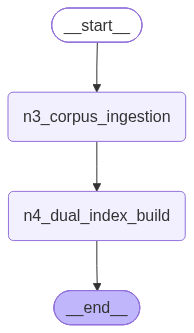

In [36]:
show_graph(ingest_graph)

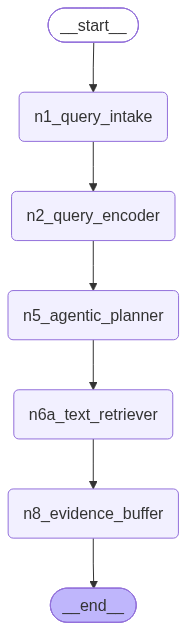

In [37]:
show_graph(query_graph)

## 7. Modality routing: the planner picks a tool (N6a / N6b / N6c, N7)

The first place the graph makes a *decision*. Until now every edge was unconditional. A
**conditional edge** calls a function that returns the name of the next route:

```python
g.add_conditional_edges("n5_agentic_planner", route_tool, {
    "text":   "n6a_text_retriever",
    "table":  "n6b_table_retriever",
    "figure": "n6c_figure_retriever",
})
```

**A conditional function cannot write to state.** It receives the state and returns a
route name - that is all. The planner already wrote its choice into `action`; the
router only reads it.

The same mechanism decides **zooming**. A page-level match says which page holds a chart,
not what its curve does, so a *small* figure is sent through N7, which re-renders the
region at 300 dpi. The router reads the figure's size, not the question.

Each tool keeps what the proofs need later: N6b keeps the box of **every cell**, N6c
keeps ColQwen2's **patch similarity map** - the raw material of N10b's boxes.

In [38]:
TOOL_NODES = {"text": "n6a_text_retriever", "table": "n6b_table_retriever",
              "figure": "n6c_figure_retriever"}


def route_tool(state: AgentState) -> str:
    # Conditional edge out of N5: the tool the planner chose. Returns a ROUTE NAME only.
    return state["action"]["tool"]

In [39]:
def table_retriever(query: str, k: int = TOP_K) -> list:
    # Rank tables by caption + cell text; return each with every cell's box.
    ranked = sorted(CORPUS["tables"], key=lambda t: -score(query, table_text(t)))
    found = []
    for t in ranked[:k]:
        s = score(query, table_text(t))
        if s <= 0:
            continue
        cells = [{"row": row[0], "col": t["header"][c], "value": value,
                  "bbox": t["cell_boxes"][r + 1][c]}
                 for r, row in enumerate(t["rows"]) for c, value in enumerate(row)]
        found.append(Evidence("table", t["id"], t["page"], table_text(t), t["bbox"],
                              "TableRetriever", s, query=query, label=t["label"], cells=cells))
    return found


#N6b
def n6b_table_retriever(state: AgentState) -> dict:
    # N6b -- TableRetriever: a table plus the page coordinates of every cell.
    #
    # Real version: ColQwen2 finds pages whose best patch is a table, the Table
    # Transformer recovers the grid, and each cell's text is read from the PDF at
    # that position. Keeping the cell boxes is what makes N10b possible.
    action = state.get("action")
    assert action and action["tool"] == "table", "N6b: the planner did not ask for a table"
    found = table_retriever(action["query"])
    return {"new_evidence": found,
            "events": step("N6b", describe_found(found), short="TableRetriever")}

In [40]:
def fake_similarity_map(figure: dict, strength: float = 0.8) -> np.ndarray:
    # Stand-in for ColQwen2's per-patch similarity to the query, on PATCH_GRID.
    # Patches whose centre falls inside the figure score high, the rest low, plus
    # seeded noise. Real version: MaxSim of the query tokens against each page
    # patch, which colpali-engine returns as exactly this kind of grid.
    rows, cols = PATCH_GRID
    ys = (np.arange(rows) + 0.5) * PAGE_H / rows
    xs = (np.arange(cols) + 0.5) * PAGE_W / cols
    x0, y0, x1, y1 = figure["bbox"]
    inside = ((ys[:, None] >= y0) & (ys[:, None] <= y1)) & ((xs[None, :] >= x0) & (xs[None, :] <= x1))
    noise = np.random.default_rng(SEED).normal(0.0, 0.03, size=(rows, cols))
    return np.where(inside, strength, 0.1 * strength) + noise


def figure_retriever(query: str, ref: Optional[str] = None, k: int = TOP_K) -> list:
    # Find figures: by number if the question names one, otherwise by caption.
    if ref:
        ranked = [(1.0, f) for f in CORPUS["figures"] if f["label"] == f"Figure {ref}"]
    else:
        ranked = sorted(((score(query, f["caption"]), f) for f in CORPUS["figures"]),
                        key=lambda sf: -sf[0])
    return [Evidence("figure", f["id"], f["page"], f["caption"], f["bbox"], "FigureRetriever",
                     s, query=query, label=f["label"], similarity=fake_similarity_map(f))
            for s, f in ranked[:k] if s > 0]


#N6c
def n6c_figure_retriever(state: AgentState) -> dict:
    # N6c -- FigureRetriever (ColPali): charts and plots from the page index.
    #
    # Real version: ColQwen2 MaxSim against the page index, no OCR. It keeps the
    # per-patch similarity map, because N10b turns that map into a bounding box.
    action = state.get("action")
    assert action and action["tool"] == "figure", "N6c: the planner did not ask for a figure"
    found = figure_retriever(action["query"], ref=state["query_filters"]["refs"].get("figure"))
    return {"new_evidence": found,
            "events": step("N6c", describe_found(found), short="FigureRetriever")}

In [41]:
#N7
def n7_region_zoom(state: AgentState) -> dict:
    # N7 -- Region Zoom. Crop the figure and re-encode it at higher resolution.
    #
    # A page-level match says which page holds the chart, not what its curve does;
    # the zoomed view is what the generator reads. Real version: PyMuPDF re-renders
    # the region at 300 dpi and ColQwen2 re-encodes the crop.
    figures = [e for e in state.get("new_evidence", []) if e.kind == "figure"]
    assert figures, "N7: N6c returned no figure to zoom into"
    zoomed = []
    for f in figures:
        w_px = round((f.bbox[2] - f.bbox[0]) / 72 * 300)
        h_px = round((f.bbox[3] - f.bbox[1]) / 72 * 300)
        zoomed.append(Evidence("figure", f.source, f.page, f"Zoomed view (300 dpi) of: {f.content}",
                               f.bbox, "RegionZoom", f.score, query=f.query, label=f.label,
                               crop=FakeTensor((h_px, w_px, 3), "300 dpi crop")))
    return {"new_evidence": state["new_evidence"] + zoomed,
            "events": step("N7", f"re-rendered {len(zoomed)} region(s) at 300 dpi -> "
                                 f"{zoomed[0].crop.shape}", short="RegionZoom")}


def route_zoom(state: AgentState) -> str:
    # Conditional edge out of N6c: zoom when the figure is small on its page (dense
    # detail), otherwise go straight to the buffer. Returns a ROUTE NAME only.
    figures = [e for e in state.get("new_evidence", []) if e.kind == "figure"]
    if not figures:
        return "buffer"
    x0, y0, x1, y1 = figures[0].bbox
    return "zoom" if (x1 - x0) * (y1 - y0) / (PAGE_W * PAGE_H) < ZOOM_IF_AREA_BELOW else "buffer"

In [42]:
def build_routing_graph():
    # Step 2 graph: the planner chooses among three tools; small figures are zoomed.
    g = StateGraph(AgentState)

    g.add_node("n1_query_intake",      n1_query_intake)
    g.add_node("n2_query_encoder",     n2_query_encoder)
    g.add_node("n5_agentic_planner",   n5_agentic_planner)
    g.add_node("n6a_text_retriever",   n6a_text_retriever)
    g.add_node("n6b_table_retriever",  n6b_table_retriever)
    g.add_node("n6c_figure_retriever", n6c_figure_retriever)
    g.add_node("n7_region_zoom",       n7_region_zoom)
    g.add_node("n8_evidence_buffer",   n8_evidence_buffer)

    g.add_edge(START, "n1_query_intake")
    g.add_edge("n1_query_intake",  "n2_query_encoder")
    g.add_edge("n2_query_encoder", "n5_agentic_planner")

    # one conditional edge, three tools
    g.add_conditional_edges("n5_agentic_planner", route_tool, TOOL_NODES)
    g.add_conditional_edges("n6c_figure_retriever", route_zoom, {
        "zoom":   "n7_region_zoom",
        "buffer": "n8_evidence_buffer",
    })

    g.add_edge("n6a_text_retriever",  "n8_evidence_buffer")
    g.add_edge("n6b_table_retriever", "n8_evidence_buffer")
    g.add_edge("n7_region_zoom",      "n8_evidence_buffer")
    g.add_edge("n8_evidence_buffer",  END)

    return g.compile()

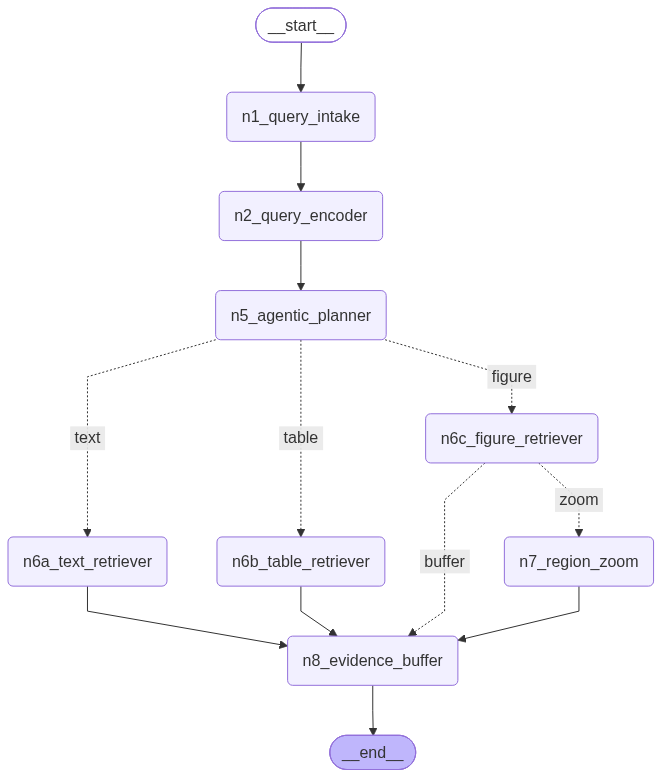

In [43]:
routing_graph = build_routing_graph()
show_graph(routing_graph)

In [44]:
# A: each kind of question reaches its own tool
TABLE_QUERY  = "Which table reports accuracy for each test subset?"
FIGURE_QUERY = "How does the validation loss change after epoch 10 in Figure 2?"

TRACE = False
cases = {TEXT_QUERY: ("text", "c3"), TABLE_QUERY: ("table", "t3"), FIGURE_QUERY: ("figure", "f2")}
for q, (kind, source) in cases.items():
    out = routing_graph.invoke(new_state(q))
    tools = ", ".join(e.tool for e in out["evidence"])
    print(f"  {kind:6s} -> {tools:32s} <- {q}")
    assert out["evidence"][0].kind == kind and out["evidence"][0].source == source
TRACE = True

print()
print("OK: the planner routed each question to the tool for its modality")

  text   -> TextRetriever                    <- How many epochs is the model trained for?
  table  -> TableRetriever                   <- Which table reports accuracy for each test subset?
  figure -> FigureRetriever, RegionZoom      <- How does the validation loss change after epoch 10 in Figure 2?

OK: the planner routed each question to the tool for its modality


In [45]:
# B: the zoom router reads the figure's size, not the question
saved = ZOOM_IF_AREA_BELOW
TRACE = False
try:
    ZOOM_IF_AREA_BELOW = 0.30
    zoomed = routing_graph.invoke(new_state(FIGURE_QUERY))
    ZOOM_IF_AREA_BELOW = 0.05        # now Figure 2 (11.8% of its page) counts as large
    direct = routing_graph.invoke(new_state(FIGURE_QUERY))
finally:
    ZOOM_IF_AREA_BELOW, TRACE = saved, True

fig2 = CORPUS["figures"][0]["bbox"]
share = (fig2[2] - fig2[0]) * (fig2[3] - fig2[1]) / (PAGE_W * PAGE_H)
print(f"Figure 2 covers {share:.1%} of its page")
print("  threshold 0.30 ->", [e.tool for e in zoomed["evidence"]])
print("  threshold 0.05 ->", [e.tool for e in direct["evidence"]])
assert [e.tool for e in zoomed["evidence"]] == ["FigureRetriever", "RegionZoom"]
assert [e.tool for e in direct["evidence"]] == ["FigureRetriever"]
print("OK: the figure is zoomed only while the threshold is above its share of the page")

Figure 2 covers 11.8% of its page
  threshold 0.30 -> ['FigureRetriever', 'RegionZoom']
  threshold 0.05 -> ['FigureRetriever']
OK: the figure is zoomed only while the threshold is above its share of the page


## 8. The Sufficiency Gate (G1) and the retrieval loop

G1 runs **before** generation and asks one question: *can this be answered from what
has actually been retrieved?* If not, control goes back to the planner.

In code, the red diamond is two pieces:

* **`g1_sufficiency_check`** is a node. It inspects the buffer and **writes** a verdict:
  which sub-goals are still uncovered, and what is missing.
* **`sufficiency_gate`** is the conditional function. It **reads** that verdict and
  returns a route name.

```python
g.add_conditional_edges("g1_sufficiency_check", sufficiency_gate, {
    "sufficient":     "n9_grounded_generator",   # (END until Section 9)
    "retrieve_again": "replan_prep",
    "exhausted":      "abstain",
})
```

**The loop needs somewhere to put its counter.** A conditional function cannot write
state, so the retry branch cannot point straight back at N5 - *something* has to
increment the round counter that makes the loop terminate. That is what `replan_prep`
is: the body of the red dashed edge in Figure 4.1.

**The counter is not optional.** LangGraph does have a `recursion_limit` (25 by default)
that will eventually stop a runaway graph, but it stops it by raising
`GraphRecursionError` - an accident, not a decision. Our counter makes exhaustion a
*designed* outcome: `abstain` reports `status="insufficient_evidence"` and what is
missing, instead of answering anyway. For a literature-review tool this is the right
failure: a researcher can act on a stated gap, but cannot detect a fabrication.

In [46]:
def covers(evidence: list, goal: dict) -> bool:
    # A sub-goal is covered by evidence of the right kind that shares words with it.
    # A text sub-goal can be answered by any kind; a table or figure one needs its own.
    kinds = {"text": {"text", "table", "figure"}, "table": {"table"}, "figure": {"figure"}}
    return any(e.kind in kinds[goal["modality"]] and score(goal["text"], e.content) > 0
               for e in evidence)


#G1
def g1_sufficiency_check(state: AgentState) -> dict:
    # G1 -- Sufficiency Gate: can the question be answered from the buffer?
    #
    # Real version: the vision-language model as judge, returning JSON
    # {"sufficient": bool, "missing": str}. The stand-in: every sub-goal must be
    # covered, and every name the question insists on must appear in the evidence.
    # Writes the verdict; the routing is done by sufficiency_gate.
    goals, evidence = state.get("sub_goals"), state.get("evidence", [])
    assert goals, "G1: N1 has not run (no sub_goals in state)"
    uncovered = [i for i, g in enumerate(goals) if not covers(evidence, g)]
    text = " ".join(e.content.lower() for e in evidence)
    absent = [x for x in state["query_filters"]["entities"] if x.lower() not in text]
    missing = ([f"{goals[i]['modality']} evidence for sub-goal {i + 1}" for i in uncovered]
               + [f"any mention of '{x}'" for x in absent])
    verdict = {"sufficient": not missing, "uncovered": uncovered, "missing": "; ".join(missing)}
    msg = "SUFFICIENT" if not missing else f"INSUFFICIENT: missing {verdict['missing']}"
    return {"sufficiency": verdict,
            "events": step("G1", msg, short="G1 pass" if not missing else "G1 reject")}

In [47]:
def sufficiency_gate(state: AgentState) -> str:
    # G1's routing -- the red diamond. Returns a ROUTE NAME only; it must not return
    # a state update, since LangGraph ignores anything but the route.
    if state["sufficiency"]["sufficient"]:
        return "sufficient"
    if state["round"] >= MAX_ROUNDS:
        trace("GATE", f"round {state['round']}/{MAX_ROUNDS} spent -> exhausted")
        return "exhausted"
    return "retrieve_again"

In [48]:
def replan_prep(state: AgentState) -> dict:
    # The body of the red dashed edge back to N5. Owns the round counter -- the part
    # that makes the retrieval loop terminate.
    n = state["round"] + 1
    return {"round": n, "events": step("REPLN", f"round {n}/{MAX_ROUNDS}: back to the planner")}

In [49]:
def abstain(state: AgentState) -> dict:
    # Graceful exit once the round budget is spent: report the gap, never guess.
    # Keeps the evidence it did find, so the report can say what was found and
    # exactly what is still missing.
    missing = state["sufficiency"]["missing"]
    return {"status": "insufficient_evidence",
            "events": step("ABSTN", f"no answer after {state['round']} round(s); missing {missing}",
                           short="abstain")}

In [50]:
def build_gated_graph():
    # Step 3 graph: routing + G1 + the bounded retrieval loop.
    g = StateGraph(AgentState)

    g.add_node("n1_query_intake",      n1_query_intake)
    g.add_node("n2_query_encoder",     n2_query_encoder)
    g.add_node("n5_agentic_planner",   n5_agentic_planner)
    g.add_node("n6a_text_retriever",   n6a_text_retriever)
    g.add_node("n6b_table_retriever",  n6b_table_retriever)
    g.add_node("n6c_figure_retriever", n6c_figure_retriever)
    g.add_node("n7_region_zoom",       n7_region_zoom)
    g.add_node("n8_evidence_buffer",   n8_evidence_buffer)
    g.add_node("g1_sufficiency_check", g1_sufficiency_check)
    g.add_node("replan_prep",          replan_prep)
    g.add_node("abstain",              abstain)

    g.add_edge(START, "n1_query_intake")
    g.add_edge("n1_query_intake",  "n2_query_encoder")
    g.add_edge("n2_query_encoder", "n5_agentic_planner")
    g.add_conditional_edges("n5_agentic_planner", route_tool, TOOL_NODES)
    g.add_conditional_edges("n6c_figure_retriever", route_zoom, {
        "zoom": "n7_region_zoom", "buffer": "n8_evidence_buffer"})
    g.add_edge("n6a_text_retriever",  "n8_evidence_buffer")
    g.add_edge("n6b_table_retriever", "n8_evidence_buffer")
    g.add_edge("n7_region_zoom",      "n8_evidence_buffer")
    g.add_edge("n8_evidence_buffer",  "g1_sufficiency_check")

    # the red diamond
    g.add_conditional_edges("g1_sufficiency_check", sufficiency_gate, {
        "sufficient":     END,
        "retrieve_again": "replan_prep",
        "exhausted":      "abstain",
    })
    g.add_edge("replan_prep", "n5_agentic_planner")      # the red dashed loop
    g.add_edge("abstain", END)

    return g.compile()

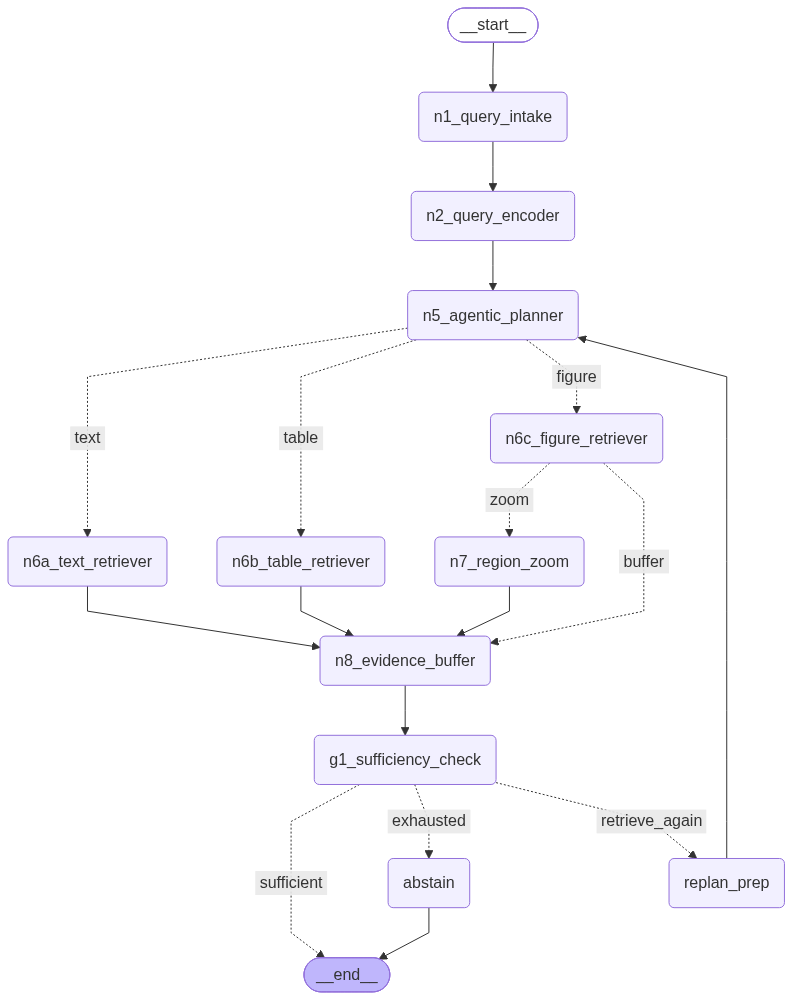

In [51]:
gated_graph = build_gated_graph()
show_graph(gated_graph)

In [52]:
def run_case(title: str, question: str, expect_status: str, expect_rounds: int):
    # Run one question through the gated graph and check how the loop ended.
    print(f"=== {title} " + "=" * max(0, 50 - len(title)))
    out = gated_graph.invoke(new_state(question))
    rejections = sum(e["short"] == "G1 reject" for e in out["events"])
    print(f"  -> status={out['status']!r}  rounds={out['round']}  G1 rejections={rejections}")
    assert out["status"] == expect_status, f"expected status {expect_status!r}, got {out['status']!r}"
    assert out["round"] == expect_rounds, f"expected {expect_rounds} round(s), got {out['round']}"
    print("  OK\n")
    return out

In [53]:
UNANSWERABLE = "What accuracy does the model reach on the Swahili test set?"

_ = run_case("A: enough evidence at once", TEXT_QUERY,
             expect_status="ok", expect_rounds=1)

case_b = run_case("B: running example, needs a second round", QUERY,
                  expect_status="ok", expect_rounds=2)

_ = run_case("C: never sufficient, abstains", UNANSWERABLE,
             expect_status="insufficient_evidence", expect_rounds=MAX_ROUNDS)

print("PASS: G1 lets sufficient evidence through, loops with a bound, and abstains instead of guessing")

=== A: enough evidence at once ========================
  [N1   ] 1 sub-goal(s): (1) text: How many epochs is the model trained for
  [N2   ] query -> (768,), refs={}, must mention=[]
  [N5   ] round 1: text <- "How many epochs is the model trained for"
  [N6a  ] c3 (page 1, score 1.5): "We train for 20 epochs with early stopping on th..."
  [N8   ] added E1=text/c3; buffer holds 1 item(s)
  [G1   ] SUFFICIENT
  -> status='ok'  rounds=1  G1 rejections=0
  OK

=== B: running example, needs a second round ==========
  [N1   ] 2 sub-goal(s): (1) text: Does the reported accuracy gain in Section 4 hold for the low-resource subset; (2) table: Which table reports it
  [N2   ] query -> (768,), refs={'section': '4'}, must mention=['low-resource']
  [N5   ] round 1: text <- "Does the reported accuracy gain in Section 4 hold for the low-resource subset"
  [N6a  ] c4 (page 2, score 3.42): "Table 3 compares our model with the baseline on ..."
  [N8   ] added E1=text/c4; buffer holds 1 item(s)
  [G1

In [54]:
# D: N8 linked the claim to the table it cites
print("evidence:", [(e.id, e.kind, e.source) for e in case_b["evidence"]])
print("links   :", case_b["links"])
assert ("E1", "E2", "same page, text cites Table 3") in case_b["links"]
print("OK: the Results paragraph and Table 3 are linked -- one piece of evidence, not two")

evidence: [('E1', 'text', 'c4'), ('E2', 'table', 't3')]
links   : [('E1', 'E2', 'same page, text cites Table 3')]
OK: the Results paragraph and Table 3 are linked -- one piece of evidence, not two


## 9. The Grounded Generator (N9) and the Faithfulness Gate (G2)

The hallucination gate. Every claim N9 writes is checked against the buffer; anything
unsupported sends the draft back.

### Citations are the point

Every claim carries a `cites` list: the exact evidence it rests on - a word-for-word
quote, or a table cell with its value:

```python
{"text":  "Table 3 reports the low-resource subset separately: Baseline 71.3, Ours 73.0, Gain +1.7.",
 "cites": [{"evidence": "E2", "cell": ("Low-resource", "Baseline"), "value": "71.3"}, ...]}
```

So G2 never has to judge prose. It runs four **equality tests**: the cited evidence is in
the buffer; a quote is word-for-word in it; a cell value equals that cell in the buffer;
and every number in the sentence is vouched for by one of its citations. Because N9 can
read nothing but the buffer, there is one ground-truth surface to test against - this is
the payoff of the "only N8 adds evidence" rule.

### The loop needs somewhere to put its counter

Same shape as the retrieval loop. `faithfulness_gate` returns a route and cannot write
state, so `rewrite_prep` owns `rewrite_count`. When the budget is spent,
`drop_unsupported` **withholds** the claims that still fail - marks them, so the report
can say plainly what was withheld - and publishes the rest.

### A plain list, not a reducer

`faith_failures` is replaced on every pass. With `Annotated[list, operator.add]` the
failures of the first draft would still be in the list after a successful rewrite, and a
corrected answer would look broken. Reducers are for fields written by **parallel**
nodes; a field written by a single node wants plain last-write-wins.

### Injection knobs

`HALLUCINATE_ONCE` makes the first draft misquote one number; `HALLUCINATE_ALWAYS` makes
every draft do it. The misquote changes the prose **and** the citation, so the two agree
- exactly the failure mode G2 exists to catch. The stand-in generator never does this on
its own.

In [55]:
# Knobs for the generator stand-in. Module-level keeps every run deterministic;
# Section 11 sets them per scenario and always puts them back.
HALLUCINATE_ONCE   = False       # the first draft misquotes one number, later drafts are honest
HALLUCINATE_ALWAYS = False       # every draft misquotes it -- exercises the rewrite budget
TABLE_CLAIM_STYLE  = "honest"    # Section 15: "honest" | "misattributed" | "uncited"

In [56]:
def cite_cell(ev: Evidence, row: str, col: str) -> dict:
    # A citation of one table cell: which evidence, which cell, and its value.
    cell = next(c for c in ev.cells if c["row"] == row and c["col"] == col)
    return {"evidence": ev.id, "cell": (row, col), "value": cell["value"]}


def text_claims(ev: Evidence) -> list:
    # Quote the sentence that best matches what the paragraph was retrieved for.
    best = max(sentences(ev.content), key=lambda s: score(ev.query, s))
    return [{"text": f'Section {ev.section} states: "{best}"',
             "cites": [{"evidence": ev.id, "quote": best}]}]


def table_claims(ev: Evidence, entities: list) -> list:
    # Report the row the question asks about, then compare it with the overall row.
    rows = list(dict.fromkeys(c["row"] for c in ev.cells))
    header = [c["col"] for c in ev.cells if c["row"] == rows[0]]
    asked = [r for r in rows if r.lower() in {x.lower() for x in entities}]
    claims = []
    for row in asked:
        cites = [cite_cell(ev, row, col) for col in header[1:]]
        claims.append({"text": f"{ev.label} reports the {row.lower()} subset separately: "
                               + ", ".join(f"{c['cell'][1]} {c['value']}" for c in cites) + ".",
                       "cites": cites})
    overall = next((r for r in rows if r.lower() in ("all", "overall", "average")), None)
    if asked and overall and "Gain" in header:
        mine, total = cite_cell(ev, asked[0], "Gain"), cite_cell(ev, overall, "Gain")
        if TABLE_CLAIM_STYLE == "misattributed":          # Section 15: another row's value
            other = next(r for r in rows if r not in (asked[0], overall))
            mine = cite_cell(ev, other, "Gain")
        holds = "does hold" if float(mine["value"]) > 0 else "does not hold"
        size = ("but it is smaller" if float(mine["value"]) < float(total["value"])
                else "and it is at least as large")
        text = (f"So the gain {holds} for the {asked[0].lower()} subset, {size}: "
                f"{mine['value']} points versus {total['value']} overall.")
        if TABLE_CLAIM_STYLE == "uncited":                  # Section 15: a number nobody cites
            text += " That is 61% of the high-resource gain."
        claims.append({"text": text, "cites": [mine, total], "conclusion": True})
    first_line = ev.content.splitlines()[0]
    return claims or [{"text": f"The most relevant table is {first_line}",
                       "cites": [{"evidence": ev.id, "quote": first_line}]}]


def figure_claims(ev: Evidence, evidence: list) -> list:
    # What the figure shows. A vision-language model reads the zoomed crop; the
    # stand-in states the caption, citing the figure and its zoomed view.
    zooms = [z.id for z in evidence if z.tool == "RegionZoom" and z.source == ev.source]
    what, *rest = sentences(ev.content.split(":", 1)[1])
    claims = [{"text": f"{ev.label} plots the {what[0].lower() + what[1:]}",
               "cites": [{"evidence": ev.id, "quote": what}]}]
    for s in rest:
        claims.append({"text": s, "cites": [{"evidence": i, "quote": s} for i in [ev.id] + zooms],
                       "conclusion": True})
    return claims


def draft_claims(state: AgentState) -> list:
    # Model stand-in for N9: claims from templates, each citing its evidence.
    evidence, entities = state["evidence"], state["query_filters"]["entities"]
    claims = []
    for ev in evidence:
        if ev.kind == "text":
            claims += text_claims(ev)
        elif ev.kind == "table":
            claims += table_claims(ev, entities)
        elif ev.tool == "FigureRetriever":
            claims += figure_claims(ev, evidence)
    return claims

In [57]:
def fabricate(claims: list) -> list:
    # Misquote one number by +1: the first cited table cell if there is one,
    # otherwise the first quoted number. Prose and citation change together, so
    # they agree -- the failure mode G2 exists to catch.
    claims = [dict(c, cites=[dict(x) for x in c["cites"]]) for c in claims]   # never edit originals
    for kind in ("value", "quote"):
        for claim in claims:
            for cite in claim["cites"]:
                m = re.search(r"\d+(?:\.\d+)?", cite.get(kind, ""))
                if not m:
                    continue
                old = m.group()
                new = f"{float(old) + 1:.1f}" if "." in old else str(int(old) + 1)
                cite[kind] = cite[kind].replace(old, new, 1)
                claim["text"] = claim["text"].replace(old, new, 1)
                claim["fabricated"] = True
                return claims
    return claims

In [58]:
#N9
def n9_grounded_generator(state: AgentState) -> dict:
    # N9 -- Grounded Generator. Writes the answer from the buffer ONLY: it has no
    # access to the corpus, and every claim cites the evidence it rests on.
    #
    # Real version: Qwen2.5-VL with the buffer (text + image crops) in context,
    # asked for JSON claims with citations; on a rewrite, the rejected claims are
    # sent back with G2's reasons.
    assert state.get("evidence"), "N9: the buffer is empty -- G1 must never let this through"
    claims = draft_claims(state)
    if HALLUCINATE_ALWAYS or (HALLUCINATE_ONCE and state.get("drafts", 0) == 0):
        claims = fabricate(claims)
    n = state.get("drafts", 0) + 1
    lie = "   <-- MISQUOTED" if any(c.get("fabricated") for c in claims) else ""
    return {"claims": claims, "drafts": n,
            "events": step("N9", f"draft {n}: {len(claims)} claim(s){lie}", short=f"draft {n}")}

In [59]:
NUMBER = re.compile(r"\d+(?:\.\d+)?")


def cite_context(cite: dict, ev: Evidence) -> str:
    # Everything a citation vouches for: the quote or the cell, and where it sits.
    parts = [ev.label, f"Section {ev.section}" if ev.section else "",
             cite.get("quote", ""), cite.get("value", ""), *cite.get("cell", ())]
    return " ".join(p for p in parts if p)


def check_claim(claim: dict, evidence: dict) -> Optional[str]:
    # Why a claim is unsupported, or None if every part of it checks out.
    if not claim["cites"]:
        return "cites nothing"
    vouched = []
    for cite in claim["cites"]:
        ev = evidence.get(cite["evidence"])
        if ev is None:
            return f"cites {cite['evidence']}, which is not in the buffer"
        if "quote" in cite and cite["quote"] not in ev.content:
            return f"the quote is not in {ev.id}"
        if "cell" in cite:
            row, col = cite["cell"]
            actual = next((c["value"] for c in ev.cells if (c["row"], c["col"]) == (row, col)), None)
            if actual != cite["value"]:
                return f"{ev.id} {row}/{col} is {actual}, the claim says {cite['value']}"
        vouched.append(cite_context(cite, ev))
    known = set(NUMBER.findall(" ".join(vouched)))
    unvouched = [n for n in NUMBER.findall(claim["text"]) if n not in known]
    if unvouched:
        return f"the number {', '.join(unvouched)} is in no citation"
    return None


#G2
def g2_faithfulness_check(state: AgentState) -> dict:
    # G2 -- Faithfulness Gate. Checks every claim against the buffer, the only
    # source the generator may use. Writes the failure list, REPLACING it.
    claims = state.get("claims")
    assert claims is not None, "G2: N9 has not run (no claims in state)"
    evidence = {e.id: e for e in state["evidence"]}
    failures = []
    for i, claim in enumerate(claims):
        if claim.get("rejected"):
            continue
        reason = check_claim(claim, evidence)
        if reason:
            failures.append({"claim": i, "text": claim["text"], "reason": reason})
    for f in failures:
        trace("G2", f"REJECT claim {f['claim'] + 1}: {f['reason']}")
    msg = (f"{len(failures)} of {len(claims)} claim(s) unsupported" if failures
           else f"all {len(claims)} claim(s) verified against the buffer")
    return {"faith_failures": failures,
            "events": step("G2", msg, short="G2 reject" if failures else "G2 pass")}

In [60]:
def faithfulness_gate(state: AgentState):
    # G2's routing. Returns route names only -- a LIST when the draft is faithful,
    # because then all three proof nodes run at once (LangGraph's fan-out).
    if not state.get("faith_failures"):
        return ["links", "boxes", "trace"]
    if state.get("rewrite_count", 0) >= MAX_REWRITES:
        trace("GATE", f"rewrite budget spent ({MAX_REWRITES}) -> dropping claims")
        return "exhausted"
    return "rewrite"

In [61]:
def rewrite_prep(state: AgentState) -> dict:
    # Body of the regenerate edge: owns the counter that bounds the loop.
    n = state.get("rewrite_count", 0) + 1
    bad = [f["claim"] + 1 for f in state["faith_failures"]]
    return {"rewrite_count": n,
            "events": step("REWRT", f"pass {n}/{MAX_REWRITES}: rewrite claim(s) {bad}")}

In [62]:
def drop_unsupported(state: AgentState) -> dict:
    # Budget spent: withhold the claims that still fail rather than publish them.
    # Marks rather than deletes, so the report can say plainly what was withheld.
    bad = {f["claim"] for f in state["faith_failures"]}
    claims = [dict(c, rejected=True) if i in bad else c for i, c in enumerate(state["claims"])]
    return {"claims": claims, "status": "unsupported_claims_dropped",
            "events": step("DROP", f"withholding {len(bad)} unsupported claim(s)", short="drop")}

In [63]:
def gate_until_proofs(state: AgentState) -> str:
    # Section 9 only: the proof nodes do not exist yet, so a faithful draft ends the run.
    route = faithfulness_gate(state)
    return "faithful" if isinstance(route, list) else route


def build_generation_graph():
    # Step 4 graph: everything so far, plus N9, G2 and the bounded regenerate loop.
    g = StateGraph(AgentState)

    g.add_node("n1_query_intake",       n1_query_intake)
    g.add_node("n2_query_encoder",      n2_query_encoder)
    g.add_node("n5_agentic_planner",    n5_agentic_planner)
    g.add_node("n6a_text_retriever",    n6a_text_retriever)
    g.add_node("n6b_table_retriever",   n6b_table_retriever)
    g.add_node("n6c_figure_retriever",  n6c_figure_retriever)
    g.add_node("n7_region_zoom",        n7_region_zoom)
    g.add_node("n8_evidence_buffer",    n8_evidence_buffer)
    g.add_node("g1_sufficiency_check",  g1_sufficiency_check)
    g.add_node("replan_prep",           replan_prep)
    g.add_node("abstain",               abstain)
    g.add_node("n9_grounded_generator", n9_grounded_generator)
    g.add_node("g2_faithfulness_check", g2_faithfulness_check)
    g.add_node("rewrite_prep",          rewrite_prep)
    g.add_node("drop_unsupported",      drop_unsupported)

    g.add_edge(START, "n1_query_intake")
    g.add_edge("n1_query_intake",  "n2_query_encoder")
    g.add_edge("n2_query_encoder", "n5_agentic_planner")
    g.add_conditional_edges("n5_agentic_planner", route_tool, TOOL_NODES)
    g.add_conditional_edges("n6c_figure_retriever", route_zoom, {
        "zoom": "n7_region_zoom", "buffer": "n8_evidence_buffer"})
    g.add_edge("n6a_text_retriever",  "n8_evidence_buffer")
    g.add_edge("n6b_table_retriever", "n8_evidence_buffer")
    g.add_edge("n7_region_zoom",      "n8_evidence_buffer")
    g.add_edge("n8_evidence_buffer",  "g1_sufficiency_check")
    g.add_conditional_edges("g1_sufficiency_check", sufficiency_gate, {
        "sufficient":     "n9_grounded_generator",
        "retrieve_again": "replan_prep",
        "exhausted":      "abstain",
    })
    g.add_edge("replan_prep", "n5_agentic_planner")
    g.add_edge("abstain", END)

    g.add_edge("n9_grounded_generator", "g2_faithfulness_check")
    g.add_conditional_edges("g2_faithfulness_check", gate_until_proofs, {
        "faithful":  END,
        "rewrite":   "rewrite_prep",
        "exhausted": "drop_unsupported",
    })
    g.add_edge("rewrite_prep", "n9_grounded_generator")      # the regenerate loop
    g.add_edge("drop_unsupported", END)

    return g.compile()

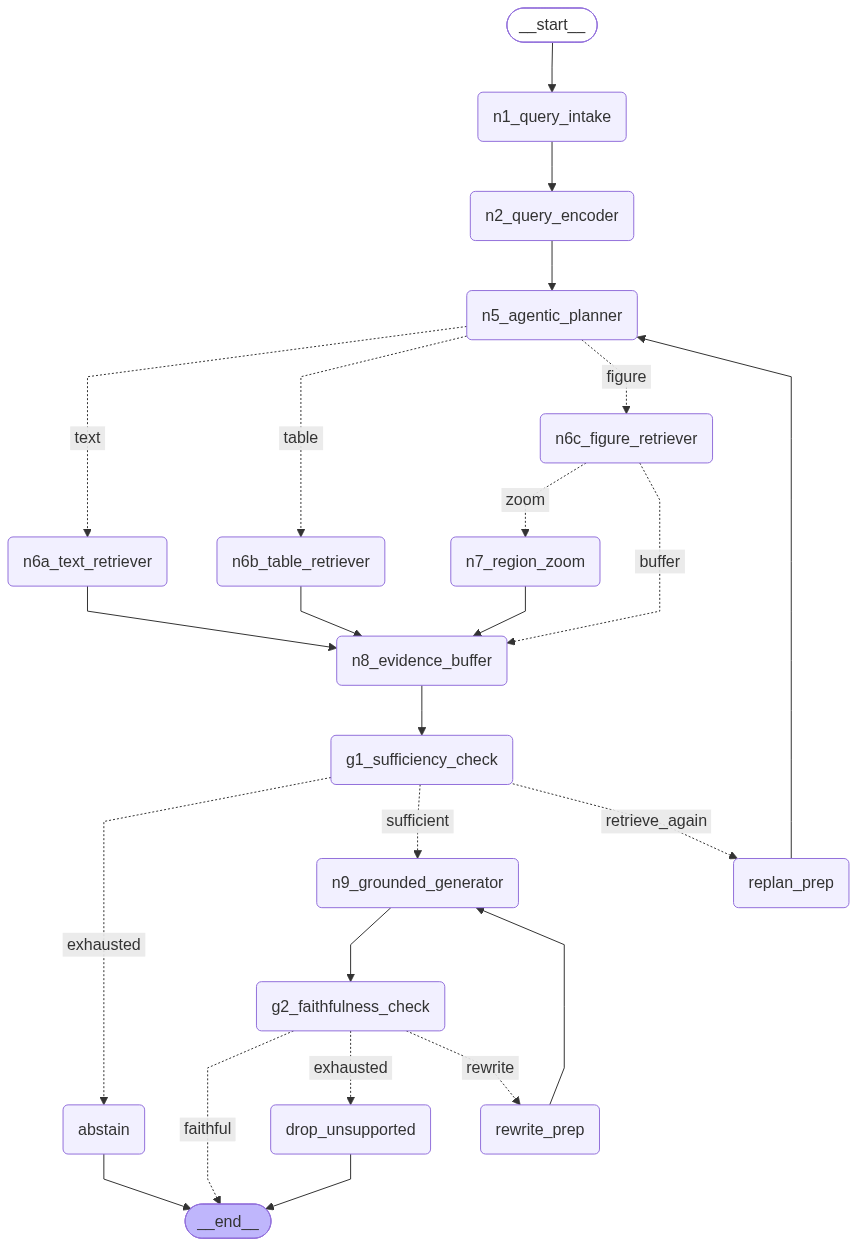

In [64]:
generation_graph = build_generation_graph()
show_graph(generation_graph)

In [65]:
# 9A: nothing misquoted -> straight through
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, False
r9a = generation_graph.invoke(new_state(QUERY))
print()
for i, c in enumerate(r9a["claims"], 1):
    print(f"  {i}. {c['text']}")
    for cite in c["cites"]:
        print(f"       cites {cite}")
assert r9a["faith_failures"] == []
assert r9a["rewrite_count"] == 0
assert r9a["status"] == "ok"
print()
print("OK: verified claims pass the gate untouched")

  [N1   ] 2 sub-goal(s): (1) text: Does the reported accuracy gain in Section 4 hold for the low-resource subset; (2) table: Which table reports it
  [N2   ] query -> (768,), refs={'section': '4'}, must mention=['low-resource']
  [N5   ] round 1: text <- "Does the reported accuracy gain in Section 4 hold for the low-resource subset"
  [N6a  ] c4 (page 2, score 3.42): "Table 3 compares our model with the baseline on ..."
  [N8   ] added E1=text/c4; buffer holds 1 item(s)
  [G1   ] INSUFFICIENT: missing table evidence for sub-goal 2; any mention of 'low-resource'
  [REPLN] round 2/3: back to the planner
  [N5   ] round 2: table <- "Which table reports it low-resource"  [G1: missing table evidence for sub-goal 2; any mention of 'low-resource']
  [N6b  ] t3 (page 2, score 2.71): "Table 3: Accuracy (%) of the baseline and our mo..."
  [N8   ] added E2=table/t3; buffer holds 2 item(s); links E1-E2
  [G1   ] SUFFICIENT
  [N9   ] draft 1: 3 claim(s)
  [G2   ] all 3 claim(s) verified against th

In [66]:
# 9B: one misquote on the first draft, caught, and rewritten
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = True, False
r9b = generation_graph.invoke(new_state(QUERY))
HALLUCINATE_ONCE = False

print()
print("rewrite_count :", r9b["rewrite_count"], "| drafts:", r9b["drafts"])
print("failures now  :", r9b["faith_failures"])
assert r9b["rewrite_count"] == 1, "the loop did not fire exactly once"
assert r9b["faith_failures"] == [], "the rewritten draft still fails"
assert not any(c.get("fabricated") for c in r9b["claims"])
assert any("Baseline 71.3" in c["text"] for c in r9b["claims"]), "the true value was not restored"
print("OK: misquote caught, draft rewritten, the true value (71.3) restored")

  [N1   ] 2 sub-goal(s): (1) text: Does the reported accuracy gain in Section 4 hold for the low-resource subset; (2) table: Which table reports it
  [N2   ] query -> (768,), refs={'section': '4'}, must mention=['low-resource']
  [N5   ] round 1: text <- "Does the reported accuracy gain in Section 4 hold for the low-resource subset"
  [N6a  ] c4 (page 2, score 3.42): "Table 3 compares our model with the baseline on ..."
  [N8   ] added E1=text/c4; buffer holds 1 item(s)
  [G1   ] INSUFFICIENT: missing table evidence for sub-goal 2; any mention of 'low-resource'
  [REPLN] round 2/3: back to the planner
  [N5   ] round 2: table <- "Which table reports it low-resource"  [G1: missing table evidence for sub-goal 2; any mention of 'low-resource']
  [N6b  ] t3 (page 2, score 2.71): "Table 3: Accuracy (%) of the baseline and our mo..."
  [N8   ] added E2=table/t3; buffer holds 2 item(s); links E1-E2
  [G1   ] SUFFICIENT
  [N9   ] draft 1: 3 claim(s)   <-- MISQUOTED
  [G2   ] REJECT claim 2: E2

In [67]:
# 9C: a generator that never corrects itself -> the claim is withheld
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, True
r9c = generation_graph.invoke(new_state(QUERY))
HALLUCINATE_ALWAYS = False

print()
print("rewrite_count :", r9c["rewrite_count"], "| status:", r9c["status"])
for c in r9c["claims"]:
    print(f"  {'WITHHELD ' if c.get('rejected') else 'published'}  {c['text']}")
withheld = [c["text"] for c in r9c["claims"] if c.get("rejected")]
assert r9c["rewrite_count"] == MAX_REWRITES
assert r9c["status"] == "unsupported_claims_dropped"
assert len(withheld) == 1 and "72.3" in withheld[0]
print()
print("OK: budget spent, the misquoted claim is withheld and the verified ones still stand")

  [N1   ] 2 sub-goal(s): (1) text: Does the reported accuracy gain in Section 4 hold for the low-resource subset; (2) table: Which table reports it
  [N2   ] query -> (768,), refs={'section': '4'}, must mention=['low-resource']
  [N5   ] round 1: text <- "Does the reported accuracy gain in Section 4 hold for the low-resource subset"
  [N6a  ] c4 (page 2, score 3.42): "Table 3 compares our model with the baseline on ..."
  [N8   ] added E1=text/c4; buffer holds 1 item(s)
  [G1   ] INSUFFICIENT: missing table evidence for sub-goal 2; any mention of 'low-resource'
  [REPLN] round 2/3: back to the planner
  [N5   ] round 2: table <- "Which table reports it low-resource"  [G1: missing table evidence for sub-goal 2; any mention of 'low-resource']
  [N6b  ] t3 (page 2, score 2.71): "Table 3: Accuracy (%) of the baseline and our mo..."
  [N8   ] added E2=table/t3; buffer holds 2 item(s); links E1-E2
  [G1   ] SUFFICIENT
  [N9   ] draft 1: 3 claim(s)   <-- MISQUOTED
  [G2   ] REJECT claim 2: E2

## 10. The three proofs (N10a-N10c), the report and the finished graph

Once G2 passes, three nodes produce the proofs **at the same time**. `faithfulness_gate`
returns a **list** of route names, and every node named runs in the same step - a
conditional function returning a list is LangGraph's fan-out:

| Node | Answers | Built from |
|---|---|---|
| **N10a** claim links | *Which evidence did this come from?* | the citations G2 already verified |
| **N10b** bounding boxes | *Where on the page is the proof?* | N6b's cell boxes; N6c's patch similarity map |
| **N10c** DAG trace | *How did the system get here?* | the `events` log every node appended to |

N10a replaces the integrated-gradients attribution of the first design: G2 has already
matched every claim to its citations, so the link is exact rather than estimated, and it
needs no gradients through a 7B model that does not fit in 12 GB unquantised.

### Two ways out, both with a trace

When G1 gives up, `abstain` routes to **N10c alone**: an abstention has no claims to
link or box, but it still owes the reader the path that led to it. N11 then writes the
"no answer" report.

### When a fan-in does *not* need `defer`

N11 has three incoming edges. It is **not** deferred, because N10a-N10c are siblings
dispatched by one fan-out: they finish in the same step, and N11 is triggered once,
after all of them. On the abstain path only N10c runs, and N11 is triggered by that one
edge. `defer=True` is only needed when parents sit at different depths.

In [68]:
def patches_to_bbox(sim: np.ndarray, keep: float = 0.5) -> tuple:
    # Turn a patch similarity map into one box in PDF points: keep every patch
    # scoring at least `keep` x the best one, take the smallest rectangle around
    # them, and scale patch indices to page coordinates. This is the algorithm the
    # real N10b runs on ColQwen2's map.
    rows, cols = sim.shape
    ys, xs = np.nonzero(sim >= keep * sim.max())
    ph, pw = PAGE_H / rows, PAGE_W / cols
    return (round(float(xs.min() * pw), 1), round(float(ys.min() * ph), 1),
            round(float((xs.max() + 1) * pw), 1), round(float((ys.max() + 1) * ph), 1))


def iou(a: tuple, b: tuple) -> float:
    # Intersection over union of two boxes -- the CGS metric of the thesis.
    ix = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union else 0.0

In [69]:
#N10a
def n10a_claim_links(state: AgentState) -> dict:
    # N10a -- claim -> source links: for every published claim, the evidence it
    # rests on and where in that evidence (the quote or the cell).
    evidence = {e.id: e for e in state["evidence"]}
    links = []
    for i, claim in enumerate(state["claims"], 1):
        if claim.get("rejected"):
            continue
        sources = []
        for cite in claim["cites"]:
            ev = evidence[cite["evidence"]]
            where = (f"\"{cite['quote'][:40]}...\"" if "quote" in cite
                     else f"cell {cite['cell'][0]} / {cite['cell'][1]}")
            sources.append({"evidence": ev.id, "kind": ev.kind, "page": ev.page, "where": where})
        links.append({"claim": i, "sources": sources})
    n_sources = sum(len(link["sources"]) for link in links)
    return {"claim_links": links,
            "events": step("N10a", f"{len(links)} claim(s) linked to {n_sources} source(s)")}

In [70]:
#N10b
def n10b_bounding_boxes(state: AgentState) -> dict:
    # N10b -- boxes [x_min, y_min, x_max, y_max] on the page, in PDF points.
    # Table claims: the exact cells they cite (N6b kept every cell's box). Figure
    # claims: the box around the best patches of N6c's similarity map. Text claims:
    # the paragraph (Section 13 narrows it to the quoted sentence).
    evidence = {e.id: e for e in state["evidence"]}
    boxes = []
    for i, claim in enumerate(state["claims"], 1):
        if claim.get("rejected"):
            continue
        for cite in claim["cites"]:
            ev = evidence[cite["evidence"]]
            if "cell" in cite:
                cell = next(c for c in ev.cells if (c["row"], c["col"]) == tuple(cite["cell"]))
                box, what = cell["bbox"], f"{ev.label} cell {cite['cell'][0]} / {cite['cell'][1]}"
            elif ev.kind == "figure" and ev.similarity is not None:
                box, what = patches_to_bbox(ev.similarity), f"{ev.label} (patch map)"
            elif ev.kind == "figure":
                continue                    # a zoomed view points at the same region as its figure
            else:
                box, what = ev.bbox, f"Section {ev.section} paragraph"
            boxes.append({"claim": i, "evidence": ev.id, "page": ev.page,
                          "bbox": tuple(round(v, 1) for v in box), "what": what})
    regions = len({(b["page"], b["bbox"]) for b in boxes})
    return {"boxes": boxes, "events": step("N10b", f"{len(boxes)} box(es) over {regions} region(s)")}

In [71]:
#N10c
TOOL_SHORTS = ("TextRetriever", "TableRetriever", "FigureRetriever", "RegionZoom")


def n10c_dag_trace(state: AgentState) -> dict:
    # N10c -- the DAG trace: which tools ran, in what order, and every gate
    # decision, taken from the step log. The process can be checked, not trusted.
    steps = [e for e in state.get("events", []) if e["short"]]
    counts = Counter(e["short"] for e in steps)
    dag = {"path": " -> ".join(e["short"] for e in steps),
           "tool_calls": sum(counts[t] for t in TOOL_SHORTS),
           "g1_rejections": counts["G1 reject"],
           "g2_rejections": counts["G2 reject"],
           "steps": steps}
    return {"dag_trace": dag, "events": step("N10c", dag["path"])}

In [72]:
#N11
def n11_report_synthesis(state: AgentState) -> dict:
    # N11 -- Report Synthesis: the answer and its three proofs in one report.
    # Real version: the vision-language model writes the connective prose. What is
    # published, what is withheld, and in what order are policy -- they stay here.
    dag = state.get("dag_trace")
    assert dag, "N11: N10c has not run (no dag_trace in state)"
    evidence = state.get("evidence", [])
    lines = [
        f"GROUNDED ANSWER -- {state['paper_id']}",
        "=" * 72,
        f"Question  : {state['question']}",
        "Evidence  : " + (", ".join(f"{e.id} {e.kind} p.{e.page}" + (f" ({e.label})" if e.label else "")
                                     for e in evidence) or "none"),
        f"Retrieval : {state['round']} round(s), {dag['g1_rejections']} rejected by G1, "
        f"{dag['tool_calls']} tool call(s)",
        f"Trace     : {dag['path']}",
        "",
    ]
    if state.get("status") == "insufficient_evidence":
        lines += ["NO ANSWER -- the evidence is not sufficient", "-" * 72,
                  f"  still missing: {state['sufficiency']['missing']}", ""]
    else:
        boxes = defaultdict(list)
        for b in state.get("boxes", []):
            boxes[b["claim"]].append(f"p.{b['page']} {list(b['bbox'])} {b['what']}")
        kept = [(i, c) for i, c in enumerate(state["claims"], 1) if not c.get("rejected")]
        lines += [f"ANSWER ({len(kept)} claim(s))", "-" * 72]
        for i, c in kept:
            ids = ", ".join(dict.fromkeys(x["evidence"] for x in c["cites"]))
            lines.append(f"{i}. {c['text']}  [{ids}]")
            lines += [f"     box {b}" for b in boxes.get(i, [])]
        withheld = [c for c in state["claims"] if c.get("rejected")]
        if withheld:
            lines += ["", "WITHHELD -- failed verification against the buffer", "-" * 72]
            lines += [f"  {c['text']}" for c in withheld]
        lines.append("")
    return {"report": "\n".join(lines),
            "events": step("N11", f"report written ({len(lines)} lines)")}

In [73]:
#N12
def n12_final_output(state: AgentState) -> dict:
    # N12 -- the terminal node: the short answer the user reads first.
    report = state.get("report")
    assert report, "N12: N11 produced no report"
    if state.get("status") == "insufficient_evidence":
        answer = ("I could not confirm an answer from this paper. Still missing: "
                  + state["sufficiency"]["missing"] + ".")
    else:
        kept = [c for c in state["claims"] if not c.get("rejected")]
        best = next((c for c in kept if c.get("conclusion")), kept[0] if kept else None)
        answer = best["text"] if best else "Every claim failed verification; nothing can be stated."
    return {"answer": answer,
            "events": step("N12", f"status={state.get('status', 'ok')}: {answer[:64]}...")}

In [74]:
def build_grounded_agent_graph():
    # The complete query-time graph of thesis Chapter 4: every node, both gates,
    # both loops and both exits. (N3-N4 run offline, in ingest_graph.)
    g = StateGraph(AgentState)

    # --- understanding the question ----------------------------------------
    g.add_node("n1_query_intake",       n1_query_intake)
    g.add_node("n2_query_encoder",      n2_query_encoder)

    # --- planning and retrieval --------------------------------------------
    g.add_node("n5_agentic_planner",    n5_agentic_planner)
    g.add_node("n6a_text_retriever",    n6a_text_retriever)
    g.add_node("n6b_table_retriever",   n6b_table_retriever)
    g.add_node("n6c_figure_retriever",  n6c_figure_retriever)
    g.add_node("n7_region_zoom",        n7_region_zoom)
    g.add_node("n8_evidence_buffer",    n8_evidence_buffer)

    # --- G1 and the retrieval loop -------------------------------------------
    g.add_node("g1_sufficiency_check",  g1_sufficiency_check)
    g.add_node("replan_prep",           replan_prep)
    g.add_node("abstain",               abstain)

    # --- generation, G2 and the regenerate loop ------------------------------
    g.add_node("n9_grounded_generator", n9_grounded_generator)
    g.add_node("g2_faithfulness_check", g2_faithfulness_check)
    g.add_node("rewrite_prep",          rewrite_prep)
    g.add_node("drop_unsupported",      drop_unsupported)

    # --- the three proofs and the output -------------------------------------
    # NOT deferred: N10a-N10c are siblings of one fan-out, so they finish in the
    # same step and N11 is triggered once, after all of them.
    g.add_node("n10a_claim_links",      n10a_claim_links)
    g.add_node("n10b_bounding_boxes",   n10b_bounding_boxes)
    g.add_node("n10c_dag_trace",        n10c_dag_trace)
    g.add_node("n11_report_synthesis",  n11_report_synthesis)
    g.add_node("n12_final_output",      n12_final_output)

    # --- edges ----------------------------------------------------------------
    g.add_edge(START, "n1_query_intake")
    g.add_edge("n1_query_intake",  "n2_query_encoder")
    g.add_edge("n2_query_encoder", "n5_agentic_planner")

    g.add_conditional_edges("n5_agentic_planner", route_tool, TOOL_NODES)
    g.add_conditional_edges("n6c_figure_retriever", route_zoom, {
        "zoom": "n7_region_zoom", "buffer": "n8_evidence_buffer"})
    g.add_edge("n6a_text_retriever",  "n8_evidence_buffer")
    g.add_edge("n6b_table_retriever", "n8_evidence_buffer")
    g.add_edge("n7_region_zoom",      "n8_evidence_buffer")
    g.add_edge("n8_evidence_buffer",  "g1_sufficiency_check")

    g.add_conditional_edges("g1_sufficiency_check", sufficiency_gate, {
        "sufficient":     "n9_grounded_generator",
        "retrieve_again": "replan_prep",
        "exhausted":      "abstain",
    })
    g.add_edge("replan_prep", "n5_agentic_planner")      # the retrieval loop
    g.add_edge("abstain",     "n10c_dag_trace")          # an abstention still gets its trace

    g.add_edge("n9_grounded_generator", "g2_faithfulness_check")
    g.add_conditional_edges("g2_faithfulness_check", faithfulness_gate, {
        "links":     "n10a_claim_links",
        "boxes":     "n10b_bounding_boxes",
        "trace":     "n10c_dag_trace",
        "rewrite":   "rewrite_prep",
        "exhausted": "drop_unsupported",
    })
    g.add_edge("rewrite_prep", "n9_grounded_generator")  # the regenerate loop

    for proof in ("n10a_claim_links", "n10b_bounding_boxes", "n10c_dag_trace"):
        g.add_edge("drop_unsupported", proof)
        g.add_edge(proof, "n11_report_synthesis")

    g.add_edge("n11_report_synthesis", "n12_final_output")
    g.add_edge("n12_final_output", END)

    return g.compile()

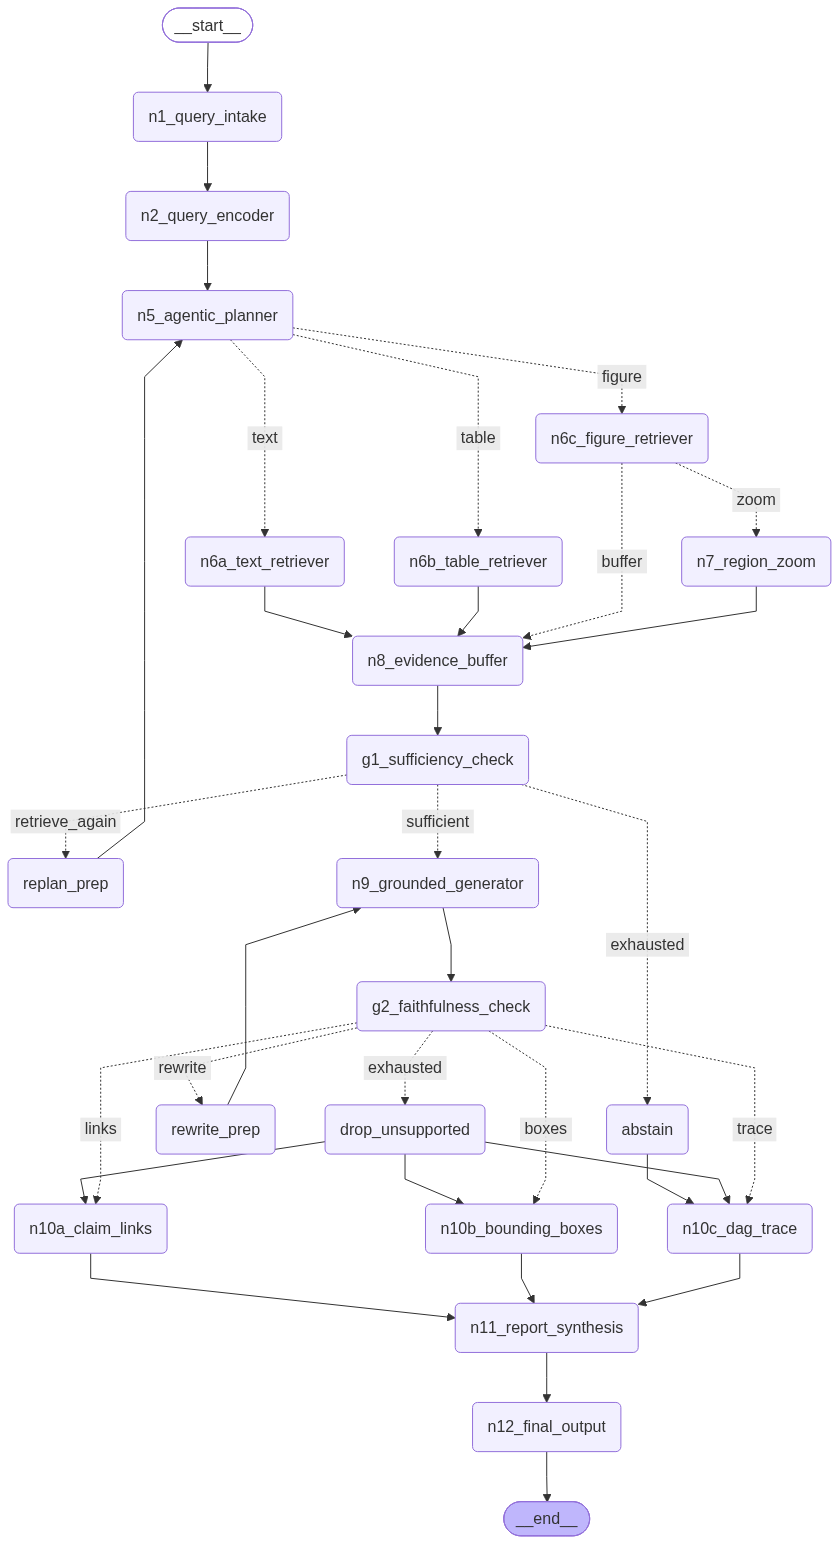

In [75]:
agent = build_grounded_agent_graph()
show_graph(agent)

In [76]:
# 10A: the running example, end to end
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, False
final = agent.invoke(new_state(QUERY))
TRACE = True

print(final["report"])
print("ANSWER:", final["answer"])

GROUNDED ANSWER -- demo-2026-001
Question  : Does the reported accuracy gain in Section 4 hold for the low-resource subset, and which table reports it?
Evidence  : E1 text p.2, E2 table p.2 (Table 3)
Retrieval : 2 round(s), 1 rejected by G1, 2 tool call(s)
Trace     : TextRetriever -> G1 reject -> TableRetriever -> G1 pass -> draft 1 -> G2 pass

ANSWER (3 claim(s))
------------------------------------------------------------------------
1. Section 4 states: "Averaged over all test data, our model achieves an accuracy gain of 3.9 points over the baseline."  [E1]
     box p.2 [60.0, 80.2, 535.0, 126.4] Section 4 paragraph
2. Table 3 reports the low-resource subset separately: Baseline 71.3, Ours 73.0, Gain +1.7.  [E2]
     box p.2 [242.5, 174.4, 322.5, 194.4] Table 3 cell Low-resource / Baseline
     box p.2 [322.5, 174.4, 402.5, 194.4] Table 3 cell Low-resource / Ours
     box p.2 [402.5, 174.4, 472.5, 194.4] Table 3 cell Low-resource / Gain
3. So the gain does hold for the low-resource

In [77]:
# 10B: coverage against thesis Figure 4.1
nodes = [n for n in agent.get_graph().nodes if not n.startswith("__")]
expected = {
    "N1-N2 the question":     ["n1_query_intake", "n2_query_encoder"],
    "N5 planner":             ["n5_agentic_planner"],
    "N6a-N7 retrieval tools": ["n6a_text_retriever", "n6b_table_retriever",
                               "n6c_figure_retriever", "n7_region_zoom"],
    "N8 evidence buffer":     ["n8_evidence_buffer"],
    "G1 + retrieval loop":    ["g1_sufficiency_check", "replan_prep", "abstain"],
    "N9 generator":           ["n9_grounded_generator"],
    "G2 + regenerate loop":   ["g2_faithfulness_check", "rewrite_prep", "drop_unsupported"],
    "N10a-N10c proofs":       ["n10a_claim_links", "n10b_bounding_boxes", "n10c_dag_trace"],
    "N11-N12 output":         ["n11_report_synthesis", "n12_final_output"],
}
for group, names in expected.items():
    missing = [n for n in names if n not in nodes]
    print(f"  {group:24s} {len(names):2d} node(s)  {'OK' if not missing else 'MISSING ' + str(missing)}")
    assert not missing
assert len(nodes) == sum(len(v) for v in expected.values()), "the graph has a node the thesis does not"

offline = [n for n in ingest_graph.get_graph().nodes if not n.startswith("__")]
print(f"\n  total: {len(nodes)} query-time nodes, plus {len(offline)} offline ({', '.join(offline)})")

  N1-N2 the question        2 node(s)  OK
  N5 planner                1 node(s)  OK
  N6a-N7 retrieval tools    4 node(s)  OK
  N8 evidence buffer        1 node(s)  OK
  G1 + retrieval loop       3 node(s)  OK
  N9 generator              1 node(s)  OK
  G2 + regenerate loop      3 node(s)  OK
  N10a-N10c proofs          3 node(s)  OK
  N11-N12 output            2 node(s)  OK

  total: 20 query-time nodes, plus 2 offline (n3_corpus_ingestion, n4_dual_index_build)


In [78]:
# 10C: Mermaid source, for pasting into the thesis
print(agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	n1_query_intake(n1_query_intake)
	n2_query_encoder(n2_query_encoder)
	n5_agentic_planner(n5_agentic_planner)
	n6a_text_retriever(n6a_text_retriever)
	n6b_table_retriever(n6b_table_retriever)
	n6c_figure_retriever(n6c_figure_retriever)
	n7_region_zoom(n7_region_zoom)
	n8_evidence_buffer(n8_evidence_buffer)
	g1_sufficiency_check(g1_sufficiency_check)
	replan_prep(replan_prep)
	abstain(abstain)
	n9_grounded_generator(n9_grounded_generator)
	g2_faithfulness_check(g2_faithfulness_check)
	rewrite_prep(rewrite_prep)
	drop_unsupported(drop_unsupported)
	n10a_claim_links(n10a_claim_links)
	n10b_bounding_boxes(n10b_bounding_boxes)
	n10c_dag_trace(n10c_dag_trace)
	n11_report_synthesis(n11_report_synthesis)
	n12_final_output(n12_final_output)
	__end__([<p>__end__</p>]):::last
	__start__ --> n1_query_intake;
	abstain --> n10c_dag_trace;
	drop_unsupported --> n10a_claim_links;
	drop_unsupported --> n10b_

### Checkpoint: three kinds of question

Five checks. The first three run one question of each kind through the finished graph;
the fourth checks the architectural rule that only N8 writes the buffer; the last checks
the *drawn* wiring, because a correct run with a wrong diagram is still a wrong figure in
the thesis.

In [79]:
# 10D: the running example -- two rounds, table cells boxed
TRACE = False
rx = agent.invoke(new_state(QUERY))
TRACE = True

cells = sorted({b["what"] for b in rx["boxes"] if "cell" in b["what"]})
print("path :", rx["dag_trace"]["path"])
print("boxes:", cells)
assert rx["status"] == "ok" and rx["round"] == 2
assert rx["dag_trace"]["g1_rejections"] == 1
assert "Table 3 cell Low-resource / Gain" in cells and "Table 3 cell All / Gain" in cells
print("OK: running example answered in two rounds, every cited cell boxed")

path : TextRetriever -> G1 reject -> TableRetriever -> G1 pass -> draft 1 -> G2 pass
boxes: ['Table 3 cell All / Gain', 'Table 3 cell Low-resource / Baseline', 'Table 3 cell Low-resource / Gain', 'Table 3 cell Low-resource / Ours']
OK: running example answered in two rounds, every cited cell boxed


In [80]:
# 10E: a figure question -- zoomed, and boxed from the patch map
TRACE = False
rf = agent.invoke(new_state(FIGURE_QUERY))
TRACE = True

fig_box = next(b["bbox"] for b in rf["boxes"] if "patch map" in b["what"])
true_box = CORPUS["figures"][0]["bbox"]
print("path     :", rf["dag_trace"]["path"])
print("patch box:", fig_box)
print("figure   :", true_box, f"-> IoU {iou(fig_box, true_box):.2f}")
assert "RegionZoom" in rf["dag_trace"]["path"]
assert iou(fig_box, true_box) >= 0.85, "the patch-map box missed the figure"
print("OK: zoomed, and the box from the similarity map lands on the figure")

path     : FigureRetriever -> RegionZoom -> G1 pass -> draft 1 -> G2 pass
patch box: (148.8, 315.8, 446.2, 526.2)
figure   : (150.0, 321.7, 445.0, 521.7) -> IoU 0.94
OK: zoomed, and the box from the similarity map lands on the figure


In [81]:
# 10F: a question the paper cannot answer -- abstains, with a trace
TRACE = False
ru = agent.invoke(new_state(UNANSWERABLE))
TRACE = True

print("status:", ru["status"])
print("path  :", ru["dag_trace"]["path"])
print("answer:", ru["answer"])
assert ru["status"] == "insufficient_evidence"
assert ru["claims"] == [] and "boxes" not in ru, "an abstention must not produce claims or boxes"
assert ru["dag_trace"]["path"].endswith("abstain")
assert "NO ANSWER" in ru["report"]
print("OK: no answer invented; the gap and the path that led to it are reported")

status: insufficient_evidence
path  : TextRetriever -> G1 reject -> TableRetriever -> G1 reject -> FigureRetriever -> G1 reject -> abstain
answer: I could not confirm an answer from this paper. Still missing: any mention of 'Swahili'.
OK: no answer invented; the gap and the path that led to it are reported


In [82]:
# 10G: only N8 writes the buffer; only the tools put evidence in its inbox
writers = defaultdict(set)
TRACE = False
for q in (QUERY, FIGURE_QUERY, UNANSWERABLE):
    for event in agent.stream(new_state(q), stream_mode="updates"):
        for node, update in event.items():
            for key in (update or {}):
                writers[key].add(node)
TRACE = True

for key in ("new_evidence", "evidence", "claims"):
    print(f"  {key:13s} written by {sorted(writers[key])}")
assert writers["evidence"] == {"n8_evidence_buffer"}
assert writers["new_evidence"] == {"n6a_text_retriever", "n6b_table_retriever",
                                   "n6c_figure_retriever", "n7_region_zoom", "n8_evidence_buffer"}
assert writers["claims"] == {"n9_grounded_generator"}
print("OK: N8 is the only writer of the buffer (it also empties the inbox the tools fill)")

  new_evidence  written by ['n6a_text_retriever', 'n6b_table_retriever', 'n6c_figure_retriever', 'n7_region_zoom', 'n8_evidence_buffer']
  evidence      written by ['n8_evidence_buffer']
  claims        written by ['n9_grounded_generator']
OK: N8 is the only writer of the buffer (it also empties the inbox the tools fill)


In [83]:
# 10H: the rendered graph has the thesis wiring and no phantom edges
edges = {(e.source, e.target) for e in agent.get_graph().edges}
for edge in [("__start__", "n1_query_intake"), ("n2_query_encoder", "n5_agentic_planner"),
             ("replan_prep", "n5_agentic_planner"), ("rewrite_prep", "n9_grounded_generator"),
             ("abstain", "n10c_dag_trace"), ("g2_faithfulness_check", "n10a_claim_links"),
             ("n10b_bounding_boxes", "n11_report_synthesis"), ("n12_final_output", "__end__")]:
    assert edge in edges, f"missing edge {edge}"
assert ("n1_query_intake", "n5_agentic_planner") not in edges
print(f"OK: {len(edges)} edges; loops, exits and fan-out drawn as wired")

OK: 32 edges; loops, exits and fan-out drawn as wired


## 11. Execution profile: what each situation costs

Running one question many times teaches nothing - the graph is deterministic, so it gives
the same trace every time. What *is* worth measuring is how the cost changes with the
situation: a question answered at once, one that needs a second round, a generator that
misquotes, a question the paper cannot answer.

For each situation we count three things:

| Count | Meaning |
|---|---|
| **steps** | supersteps - rounds of the graph; nodes in the same round run in parallel |
| **node runs** | total node executions, counting a node again each time a loop re-runs it |
| **model calls** | runs of N1, N2, N5, G1, N9 and G2 - in deployment, each one is a call to Qwen2.5-VL |

First we need a way to *record* a run instead of just getting its final state.

In [84]:
def record_run(state: AgentState) -> list:
    # Run one query and write down which node ran in which step.
    #
    # invoke() only hands back the final state. stream(stream_mode="debug") runs
    # the same graph but reports events as they happen; a "task" event means "this
    # node is running in this step" -- that is all we keep.
    #
    # Returns (step, node) pairs, e.g. [(1, "n1_query_intake"), (2, "n2_query_encoder"), ...].
    # Pairs with the same step ran in parallel.
    timeline = []
    for event in agent.stream(state, stream_mode="debug"):
        if event["type"] == "task":
            timeline.append((event["step"], event["payload"]["name"]))
    return timeline

In [85]:
# 11A: record the running example, step by step
TRACE = False
HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, False
timeline = record_run(new_state(QUERY))
TRACE = True

for s, node in timeline:
    print(f"step {s:2d}: {node}")

step_numbers = {s for s, _ in timeline}
print()
print("steps     :", len(step_numbers))
print("node runs :", len(timeline))
assert len(step_numbers) == 16, f"expected 16 steps, got {len(step_numbers)}"
assert timeline[0] == (1, "n1_query_intake"), "the first node should run in step 1"
assert sorted(n for s, n in timeline if s == 14) == ["n10a_claim_links", "n10b_bounding_boxes", "n10c_dag_trace"]
print("OK: the running example takes 16 steps; the three proofs share step 14")

step  1: n1_query_intake
step  2: n2_query_encoder
step  3: n5_agentic_planner
step  4: n6a_text_retriever
step  5: n8_evidence_buffer
step  6: g1_sufficiency_check
step  7: replan_prep
step  8: n5_agentic_planner
step  9: n6b_table_retriever
step 10: n8_evidence_buffer
step 11: g1_sufficiency_check
step 12: n9_grounded_generator
step 13: g2_faithfulness_check
step 14: n10a_claim_links
step 14: n10b_bounding_boxes
step 14: n10c_dag_trace
step 15: n11_report_synthesis
step 16: n12_final_output

steps     : 16
node runs : 18
OK: the running example takes 16 steps; the three proofs share step 14


### Setting up a situation safely

A situation is set by three global settings: `TRACE`, `HALLUCINATE_ONCE` and
`HALLUCINATE_ALWAYS`. Changing them by hand is risky - forget to change one back, and
every later cell silently runs in the wrong situation.

`run_scenario` changes them, records the run, and **always** puts them back, even if the
run crashes.

In [86]:
def run_scenario(question, lie_once: bool = False, lie_always: bool = False) -> list:
    # Set up one situation, record the run, then put every setting back.
    #   question    the question to ask
    #   lie_once    the generator misquotes on its first draft, then corrects itself
    #   lie_always  the generator misquotes on every draft
    # Returns the timeline from record_run.
    global TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS

    # 1. remember the current settings
    saved = (TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)

    # 2. set up this situation
    TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, lie_once, lie_always

    # 3. run it, and put the settings back whatever happens
    try:
        return record_run(new_state(question))
    finally:
        TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = saved

In [87]:
# 11B: a scenario changes the settings only while it runs
before = (TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
timeline = run_scenario(QUERY, lie_once=True)
after = (TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
ran_nodes = [node for _, node in timeline]

print("settings before:", before)
print("settings after :", after)
print("rewrite ran    :", "rewrite_prep" in ran_nodes)
assert "rewrite_prep" in ran_nodes, "the misquote setting did not take effect"
assert after == before, "run_scenario did not put the settings back"
print("OK: the situation applied during the run, and was undone after it")

settings before: (True, False, False)
settings after : (True, False, False)
rewrite ran    : True
OK: the situation applied during the run, and was undone after it


In [88]:
# 11C: settings are put back even when the run crashes
before = (TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
try:
    run_scenario(None, lie_always=True)          # N1 cannot work without a question
    crashed = False
except Exception as e:
    crashed = True
    print("crashed as expected:", type(e).__name__)

after = (TRACE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
print("settings after crash:", after)
assert crashed, "a missing question should have crashed the run"
assert after == before, "a crash left the settings changed"
print("OK: finally restored the settings after a crash")

crashed as expected: AssertionError
settings after crash: (True, False, False)
OK: finally restored the settings after a crash


### The cost table

1. `profile` turns a timeline into counts - steps, node runs, model calls, and what
   happened along the way (rounds, zooms, rewrites, dropped or abstained).
2. `SCENARIOS` lists the situations to run. It is data, not code: adding a situation
   means adding one entry, not writing a new test.
3. Test 11D runs every scenario and prints one row per situation.

In [89]:
# Nodes that are one call to the vision-language model in deployment.
MODEL_NODES = {"n1_query_intake", "n2_query_encoder", "n5_agentic_planner",
               "g1_sufficiency_check", "n9_grounded_generator", "g2_faithfulness_check"}


def profile(timeline: list) -> dict:
    # Turn a timeline from record_run into the counts for the cost table.
    ran = [node for _, node in timeline]
    return {
        "steps":       len({s for s, _ in timeline}),
        "node_runs":   len(timeline),
        "model_calls": sum(node in MODEL_NODES for node in ran),
        "rounds":      ran.count("n5_agentic_planner"),
        "zooms":       ran.count("n7_region_zoom"),
        "rewrites":    ran.count("rewrite_prep"),
        "dropped":     "drop_unsupported" in ran,
        "abstained":   "abstain" in ran,
    }

In [90]:
THREE_PART_QUERY = ("Does the accuracy gain in Section 4 hold for the low-resource subset; "
                    "which table reports it; and how does the validation loss in Figure 2 "
                    "change after epoch 10?")

# The situations. A key that is left out (for example lie_once) means "no".
SCENARIOS = [
    {"name": "Text question, one round",          "question": TEXT_QUERY},
    {"name": "Figure question, with zoom",        "question": FIGURE_QUERY},
    {"name": "Running example, two rounds",       "question": QUERY},
    {"name": "Running example, one misquote",     "question": QUERY, "lie_once": True},
    {"name": "Running example, never corrected",  "question": QUERY, "lie_always": True},
    {"name": "Unanswerable, abstains",            "question": UNANSWERABLE},
    {"name": "Three sub-goals, never corrected",  "question": THREE_PART_QUERY, "lie_always": True},
]
print(len(SCENARIOS), "scenarios")

7 scenarios


In [91]:
# 11D: run every scenario and build the cost table
cost_rows = []
for sc in SCENARIOS:
    timeline = run_scenario(sc["question"], lie_once=sc.get("lie_once", False),
                            lie_always=sc.get("lie_always", False))
    cost_rows.append({"scenario": sc["name"], **profile(timeline)})

header = (f"{'scenario':36s} {'rounds':>6s} {'zooms':>5s} {'rewrites':>8s} "
          f"{'steps':>5s} {'node runs':>9s} {'model calls':>11s}")
print(header)
print("-" * len(header))
for r in cost_rows:
    print(f"{r['scenario']:36s} {r['rounds']:6d} {r['zooms']:5d} {r['rewrites']:8d} "
          f"{r['steps']:5d} {r['node_runs']:9d} {r['model_calls']:11d}")

# What each run measured when this cell was written. If a later change to the
# graph alters a cost, this is where you find out.
EXPECTED_COSTS = {                               # (steps, node runs, model calls)
    "Text question, one round":          (11, 13,  6),
    "Figure question, with zoom":        (12, 14,  6),
    "Running example, two rounds":       (16, 18,  8),
    "Running example, one misquote":     (19, 21, 10),
    "Running example, never corrected":  (23, 25, 12),
    "Unanswerable, abstains":            (20, 20,  8),
    "Three sub-goals, never corrected":  (29, 31, 14),
}
for r in cost_rows:
    got = (r["steps"], r["node_runs"], r["model_calls"])
    assert got == EXPECTED_COSTS[r["scenario"]], f"{r['scenario']}: got {got}"
print()
print(f"OK: all {len(cost_rows)} scenarios cost what they cost before")

scenario                             rounds zooms rewrites steps node runs model calls
--------------------------------------------------------------------------------------
Text question, one round                  1     0        0    11        13           6
Figure question, with zoom                1     1        0    12        14           6
Running example, two rounds               2     0        0    16        18           8
Running example, one misquote             2     0        1    19        21          10
Running example, never corrected          2     0        2    23        25          12
Unanswerable, abstains                    3     0        0    20        20           8
Three sub-goals, never corrected          3     1        2    29        31          14

OK: all 7 scenarios cost what they cost before


### The cost formula

The table above was **measured**. Now we **predict** the same numbers without running
anything, just by counting steps along the graph, and check that the two agree. If they
do, the code does exactly what the diagram says.

| Part of the run | Steps | Count |
|---|---|---|
| reading the question | N1, N2 | **2** |
| each retrieval round | N5, one tool, N8, G1 | **4** |
| a zoom inside a round | N7 | **+1** |
| going back for another round | `replan_prep` | **+1** per extra round |
| generation | N9, G2 | **2** |
| each rewrite | `rewrite_prep`, N9, G2 | **+3** |
| claims dropped | `drop_unsupported` | **+1** |
| proofs and output | [N10a N10b N10c], N11, N12 | **3** |
| abstaining instead of generating | `abstain`, N10c, N11, N12 | **4** |

So, with *R* rounds, *Z* zooms and *W* rewrites:

```
answers:   steps = 2 + 4R + Z + (R - 1) + 2 + 3W + (1 if dropped) + 3  =  6 + 5R + Z + 3W (+1)
abstains:  steps = 2 + 4R + Z + (R - 1) + 4                            =  5 + 5R + Z
```

In [92]:
def predicted_steps(rounds: int, zooms: int, rewrites: int, dropped: bool, abstained: bool) -> int:
    # How many steps a question should take, worked out from the graph's shape.
    # Nothing here runs the graph -- see the table in the cell above.
    retrieval = 2 + 4 * rounds + zooms + (rounds - 1)       # N1, N2, the rounds, replan_prep
    if abstained:
        return retrieval + 4                                # abstain, N10c, N11, N12
    return retrieval + 2 + 3 * rewrites + (1 if dropped else 0) + 3

In [93]:
# 11E: the formula predicts every measured row
print(f"{'scenario':36s} {'measured':>8s} {'formula':>7s}")
print("-" * 53)
for r in cost_rows:
    formula = predicted_steps(r["rounds"], r["zooms"], r["rewrites"], r["dropped"], r["abstained"])
    mark = "" if formula == r["steps"] else "   <-- MISMATCH"
    print(f"{r['scenario']:36s} {r['steps']:8d} {formula:7d}{mark}")
    assert formula == r["steps"], f"{r['scenario']}: measured {r['steps']}, formula {formula}"
print()
print(f"OK: the formula matches all {len(cost_rows)} measured runs")

scenario                             measured formula
-----------------------------------------------------
Text question, one round                   11      11
Figure question, with zoom                 12      12
Running example, two rounds                16      16
Running example, one misquote              19      19
Running example, never corrected           23      23
Unanswerable, abstains                     20      20
Three sub-goals, never corrected           29      29

OK: the formula matches all 7 measured runs


In [94]:
# 11F: the worst case is known before any question runs
# Every round zooms, every rewrite is used, and claims are still dropped at the end.
WORST_STEPS = predicted_steps(rounds=MAX_ROUNDS, zooms=MAX_ROUNDS, rewrites=MAX_REWRITES,
                              dropped=True, abstained=False)
# Model calls: N1 + N2, then N5 + G1 per round, then N9 + G2 per draft.
WORST_MODEL_CALLS = 2 + 2 * MAX_ROUNDS + 2 * (1 + MAX_REWRITES)

print(f"limits           : MAX_ROUNDS={MAX_ROUNDS}  MAX_REWRITES={MAX_REWRITES}")
print(f"worst steps      : {WORST_STEPS}")
print(f"worst model calls: {WORST_MODEL_CALLS}")
print()
longest = max(r["steps"] for r in cost_rows)
busiest = max(r["model_calls"] for r in cost_rows)
print(f"longest run seen : {longest} steps (a zoom in every round needs a figure per sub-goal;"
      f" this paper has one)")
print(f"most calls seen  : {busiest}")

assert all(r["steps"] <= WORST_STEPS for r in cost_rows), "a run went past the step bound"
assert all(r["model_calls"] <= WORST_MODEL_CALLS for r in cost_rows), "too many model calls"
assert busiest == WORST_MODEL_CALLS, "the three-sub-goal scenario should reach the call bound exactly"
print()
print(f"OK: no run exceeds the bounds; the worst case reaches {WORST_MODEL_CALLS} model calls exactly")

limits           : MAX_ROUNDS=3  MAX_REWRITES=2
worst steps      : 31
worst model calls: 14

longest run seen : 29 steps (a zoom in every round needs a figure per sub-goal; this paper has one)
most calls seen  : 14

OK: no run exceeds the bounds; the worst case reaches 14 model calls exactly


### The trace figure: labels and colours

The figure draws one recorded run as a timeline - one row per step, boxes side by side
when nodes ran in parallel. Node names like `n10b_bounding_boxes` are too long for a small
box, so every node gets a short label that matches Figure 4.1.

Colour has one job here: telling three kinds of node apart. Every other node stays
neutral grey, so the eye goes to the parts the thesis is about.

| Group | Nodes | Colour |
|---|---|---|
| pipeline | tools, buffer, proofs, report | grey |
| model call | N1, N2, N5, N9 | blue |
| check | the gates and correction loops | orange |

A rejected draft is shown with **hatching** rather than a third colour, so it still shows
when the thesis is printed in black and white.

In [95]:
# Figure style: short labels, colour groups and ink colours for the trace figure.
NODE_LABELS = {
    "n1_query_intake":       "N1 Intake",
    "n2_query_encoder":      "N2 Encoder",
    "n5_agentic_planner":    "N5 Planner",
    "n6a_text_retriever":    "N6a Text",
    "n6b_table_retriever":   "N6b Table",
    "n6c_figure_retriever":  "N6c Figure",
    "n7_region_zoom":        "N7 Zoom",
    "n8_evidence_buffer":    "N8 Buffer",
    "g1_sufficiency_check":  "G1 Sufficiency",
    "replan_prep":           "Replan",
    "abstain":               "Abstain",
    "n9_grounded_generator": "N9 Generator",
    "g2_faithfulness_check": "G2 Faithfulness",
    "rewrite_prep":          "Rewrite",
    "drop_unsupported":      "Drop",
    "n10a_claim_links":      "N10a Links",
    "n10b_bounding_boxes":   "N10b Boxes",
    "n10c_dag_trace":        "N10c Trace",
    "n11_report_synthesis":  "N11 Report",
    "n12_final_output":      "N12 Output",
}
CHECK_NODES = {"g1_sufficiency_check", "replan_prep", "abstain",
               "g2_faithfulness_check", "rewrite_prep", "drop_unsupported"}

ROLE_STYLE = {                          # group -> (fill colour, border colour)
    "pipeline": ("#f0efec", "#c3c2b7"),     # neutral grey
    "model":    ("#cde2fb", "#2a78d6"),     # blue
    "check":    ("#fbded2", "#eb6834"),     # orange
}
ROLE_NAMES = {"pipeline": "Pipeline node", "model": "Model call", "check": "Gate or correction loop"}

INK_TEXT, INK_NOTE, INK_MUTED = "#0b0b0b", "#52514e", "#898781"

In [96]:
def node_role(node: str) -> str:
    # Which colour group a node belongs to. Gates are model calls too; they are
    # drawn as checks, because that is their job in the graph.
    if node in CHECK_NODES:
        return "check"
    if node in MODEL_NODES:
        return "model"
    return "pipeline"

In [97]:
# 11G: every node the graph can run has a label and a colour group
graph_nodes = {n for n in agent.get_graph().nodes if not n.startswith("__")}
no_label = graph_nodes - set(NODE_LABELS)
stray = set(NODE_LABELS) - graph_nodes

groups = defaultdict(list)
for node in sorted(graph_nodes):
    groups[node_role(node)].append(node)
for role in ROLE_STYLE:
    print(f"{ROLE_NAMES[role]:24s} {len(groups[role]):2d}  e.g. {NODE_LABELS[groups[role][0]]}")
print()
print("nodes with no label :", sorted(no_label) or "none")
print("labels with no node :", sorted(stray) or "none")
assert not no_label and not stray
assert set(groups["check"]) == CHECK_NODES
print("OK: all", len(graph_nodes), "nodes have a label and a colour group")

Pipeline node            10  e.g. N10a Links
Model call                4  e.g. N1 Intake
Gate or correction loop   6  e.g. Abstain

nodes with no label : none
labels with no node : none
OK: all 20 nodes have a label and a colour group


### Drawing the trace figure

`draw_timeline` turns a recorded timeline into a picture. Everything it draws comes from
the recording - which node ran, and in which step. Only the short notes beside the boxes
are written by us, and they contain no numbers.

The figure is sized for **one column of a two-column page** (3.35 inches wide) and saved as
a **PDF**, which stays sharp at any zoom. Fonts are embedded as TrueType
(`pdf.fonttype = 42`), because many submission systems reject PDFs with Type 3 fonts.

In [98]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch


def draw_timeline(timeline: list, notes: dict = None, hatched: set = None, save_to=None):
    # Draw a recorded run: one row per step, one box per node.
    #   timeline  the (step, node) list from record_run
    #   notes     {step: text}, a short note written beside that step's box
    #   hatched   {(step, node)}, boxes to hatch, e.g. a rejected draft
    #   save_to   file path; a .pdf path gives a vector figure
    notes, hatched = notes or {}, hatched or set()
    steps = sorted({s for s, _ in timeline})
    per_step = {s: [n for t, n in timeline if t == s] for s in steps}
    n_cols = max(len(v) for v in per_step.values())

    WIDTH, LEFT, TOP, ROW, BOX_H, GAP, LEGEND = 3.35, 0.34, 0.24, 0.21, 0.16, 0.06, 0.42
    col_w = (WIDTH - LEFT - 0.04 - GAP * (n_cols - 1)) / n_cols
    height = TOP + ROW * len(steps) + LEGEND

    with plt.rc_context({"pdf.fonttype": 42, "font.size": 6.5, "hatch.linewidth": 0.6}):
        fig = plt.figure(figsize=(WIDTH, height))
        ax = fig.add_axes([0, 0, 1, 1])
        ax.set_xlim(0, WIDTH)
        ax.set_ylim(height, 0)               # y grows downwards, like reading a page
        ax.axis("off")
        ax.text(LEFT - 0.12, TOP - 0.08, "step", ha="right", va="center", color=INK_MUTED)

        for row, s in enumerate(steps):
            y = TOP + row * ROW
            ax.text(LEFT - 0.12, y + BOX_H / 2, str(s), ha="right", va="center", color=INK_MUTED)
            for col, node in enumerate(per_step[s]):
                x = LEFT + col * (col_w + GAP)
                fill, edge = ROLE_STYLE[node_role(node)]
                is_hatched = (s, node) in hatched
                ax.add_patch(FancyBboxPatch((x, y), col_w, BOX_H,
                                            boxstyle="round,pad=0,rounding_size=0.03",
                                            facecolor=fill, edgecolor=edge, linewidth=0.8,
                                            hatch="//////" if is_hatched else None))
                label_bg = dict(facecolor=fill, edgecolor="none", pad=0.8) if is_hatched else None
                ax.text(x + 0.06, y + BOX_H / 2, NODE_LABELS[node], va="center",
                        color=INK_TEXT, bbox=label_bg)
            if s in notes:
                assert len(per_step[s]) < n_cols, f"step {s} has no free space for a note"
                x = LEFT + len(per_step[s]) * (col_w + GAP)
                ax.text(x + 0.02, y + BOX_H / 2, notes[s], va="center", color=INK_NOTE, style="italic")

        handles = [Patch(facecolor=ROLE_STYLE[r][0], edgecolor=ROLE_STYLE[r][1], linewidth=0.8,
                         label=ROLE_NAMES[r]) for r in ROLE_STYLE]
        if hatched:
            fill, edge = ROLE_STYLE["model"]
            handles.append(Patch(facecolor=fill, edgecolor=edge, linewidth=0.8, hatch="//////",
                                 label="Rejected draft"))
        ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=2,
                  frameon=False, fontsize=6, handlelength=1.6, handleheight=1.0, columnspacing=1.2)
        if save_to is not None:
            fig.savefig(save_to)
    return fig

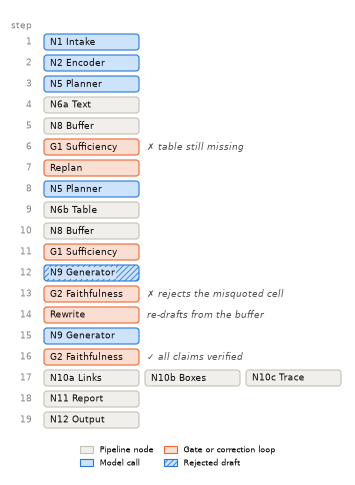

steps drawn : 19
boxes drawn : 21 | node runs recorded: 21
saved       : paper/figures/fig_execution_trace.pdf (32 KB)
OK: one box per node run, notes on the right steps, PDF saved


In [99]:
# 11H: draw the run where the first draft misquotes, and save it for the thesis
timeline = run_scenario(QUERY, lie_once=True)

# find the interesting steps from the recording, not by counting by hand
g1_reject = min(s for s, n in timeline if n == "g1_sufficiency_check")
first_draft = min(s for s, n in timeline if n == "n9_grounded_generator")
rewrite_step = min(s for s, n in timeline if n == "rewrite_prep")

fig_path = PROJECT_ROOT / "paper" / "figures" / "fig_execution_trace.pdf"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig = draw_timeline(
    timeline,
    hatched={(first_draft, "n9_grounded_generator")},
    notes={
        g1_reject:        "✗ table still missing",
        first_draft + 1:  "✗ rejects the misquoted cell",
        rewrite_step:     "re-drafts from the buffer",
        rewrite_step + 2: "✓ all claims verified",
    },
    save_to=fig_path,
)
plt.show()

boxes = [p for p in fig.axes[0].patches if isinstance(p, FancyBboxPatch)]
print("steps drawn :", len({s for s, _ in timeline}))
print("boxes drawn :", len(boxes), "| node runs recorded:", len(timeline))
print("saved       :", fig_path.relative_to(PROJECT_ROOT), f"({fig_path.stat().st_size // 1024} KB)")

# the notes must sit beside the nodes they describe
assert [n for s, n in timeline if s == g1_reject] == ["g1_sufficiency_check"]
assert [n for s, n in timeline if s == first_draft + 1] == ["g2_faithfulness_check"]
assert [n for s, n in timeline if s == rewrite_step + 2] == ["g2_faithfulness_check"]
assert len(boxes) == len(timeline), "every node run should be exactly one box"
print("OK: one box per node run, notes on the right steps, PDF saved")

### From the notebook to the thesis

**No number is typed into the thesis by hand.** The cost table is written to
`paper/tables/tab_execution_profile.tex` from `cost_rows`, the measured numbers, and the
thesis pulls it in with `\input{tables/tab_execution_profile}`. If the graph changes and
a cost moves, re-running this notebook updates the thesis.

The thesis uses shorter scenario names than the notebook, so a small dictionary maps one
to the other. It also fixes the row order.

In [100]:
# Scenario names as they appear in the thesis, in the order the thesis lists them.
PAPER_ROW_NAMES = {
    "Text question, one round":          "Text, 1 round",
    "Figure question, with zoom":        "Figure, zoom",
    "Running example, two rounds":       "Running example",
    "Running example, one misquote":     "Running ex., 1 misquote",
    "Running example, never corrected":  "Running ex., never corrected",
    "Unanswerable, abstains":            "Unanswerable",
    "Three sub-goals, never corrected":  "Worst case (3 sub-goals)",
}

In [101]:
def write_cost_table(rows: list, path) -> str:
    # Write the cost table as a LaTeX tabular, straight from measured rows. Only the
    # tabular is written: the caption stays in the thesis, the numbers stay here.
    # The thesis must load booktabs (it already does). Returns the LaTeX text.
    by_name = {r["scenario"]: r for r in rows}
    lines = [
        "% Generated by notebooks/langgraph_demo.ipynb (test 11I).",
        "% Do not edit by hand -- re-run the notebook instead.",
        r"\begin{tabular}{@{}lrrrrrr@{}}",
        r"\toprule",
        r"Scenario & $R$ & $Z$ & $W$ & Steps & Node runs & Model calls \\",
        r"\midrule",
    ]
    for notebook_name, paper_name in PAPER_ROW_NAMES.items():
        r = by_name[notebook_name]
        lines.append(f"{paper_name} & {r['rounds']} & {r['zooms']} & {r['rewrites']} & "
                     f"{r['steps']} & {r['node_runs']} & {r['model_calls']} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    text = "\n".join(lines) + "\n"
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return text

In [102]:
# 11I: write the table for the thesis, then read it back and check every number
table_path = PROJECT_ROOT / "paper" / "tables" / "tab_execution_profile.tex"
latex = write_cost_table(cost_rows, table_path)
print(latex)

assert set(PAPER_ROW_NAMES) == {r["scenario"] for r in cost_rows}, \
    "a scenario is missing from PAPER_ROW_NAMES (or a name there is misspelt)"

by_name = {r["scenario"]: r for r in cost_rows}
data_rows = [line for line in table_path.read_text(encoding="utf-8").splitlines()
             if line.count("&") == 6 and not line.startswith("Scenario")]
assert len(data_rows) == len(PAPER_ROW_NAMES)
for line, (notebook_name, paper_name) in zip(data_rows, PAPER_ROW_NAMES.items()):
    cells = [c.strip() for c in line.rstrip("\\ ").split("&")]
    r = by_name[notebook_name]
    wanted = [r["rounds"], r["zooms"], r["rewrites"], r["steps"], r["node_runs"], r["model_calls"]]
    assert cells[0] == paper_name and [int(c) for c in cells[1:]] == wanted, f"{paper_name}: mismatch"
print("saved:", table_path.relative_to(PROJECT_ROOT))
print(f"OK: all {len(data_rows)} rows in the file match the measured numbers")

% Generated by notebooks/langgraph_demo.ipynb (test 11I).
% Do not edit by hand -- re-run the notebook instead.
\begin{tabular}{@{}lrrrrrr@{}}
\toprule
Scenario & $R$ & $Z$ & $W$ & Steps & Node runs & Model calls \\
\midrule
Text, 1 round & 1 & 0 & 0 & 11 & 13 & 6 \\
Figure, zoom & 1 & 1 & 0 & 12 & 14 & 6 \\
Running example & 2 & 0 & 0 & 16 & 18 & 8 \\
Running ex., 1 misquote & 2 & 0 & 1 & 19 & 21 & 10 \\
Running ex., never corrected & 2 & 0 & 2 & 23 & 25 & 12 \\
Unanswerable & 3 & 0 & 0 & 20 & 20 & 8 \\
Worst case (3 sub-goals) & 3 & 1 & 2 & 29 & 31 & 14 \\
\bottomrule
\end{tabular}

saved: paper/tables/tab_execution_profile.tex
OK: all 7 rows in the file match the measured numbers


## 12. A question's journey through the graph

`record_run` recorded **which** node ran. Here we record **what each node wrote** into the
shared state, using `stream_mode="updates"`: every event is `{node_name: the dictionary
that node returned}`.

`describe_write` turns each of those dictionaries into one short line a person can read.
Two questions are then shown side by side, stage by stage - the same pipeline, different
evidence, different proofs.

In [103]:
def record_writes(state: AgentState) -> list:
    # Run one query and record what every node wrote into the state. Like record_run,
    # but with stream_mode="updates". Returns (node, update) pairs in order.
    writes = []
    for event in agent.stream(state, stream_mode="updates"):
        for node, update in event.items():
            writes.append((node, update or {}))
    return writes

In [104]:
def describe_write(node: str, update: dict) -> str:
    # One short, readable line for what a node wrote.
    u = update
    if node == "n1_query_intake":
        return "; ".join(f"{g['modality']}: {g['text'][:38]}" for g in u["sub_goals"])
    if node == "n2_query_encoder":
        f = u["query_filters"]
        return f"refs {f['refs'] or '-'}, must mention {f['entities'] or '-'}"
    if node == "n5_agentic_planner":
        return f"use {u['action']['tool']}"
    if node in TOOL_NODES.values() or node == "n7_region_zoom":
        return ", ".join(f"{e.tool}: {e.source}" for e in u["new_evidence"][-1:]) or "nothing"
    if node == "n8_evidence_buffer":
        return f"{len(u['evidence'])} item(s): " + ", ".join(f"{e.id} {e.kind}" for e in u["evidence"])
    if node == "g1_sufficiency_check":
        v = u["sufficiency"]
        return "sufficient" if v["sufficient"] else f"missing {v['missing']}"
    if node == "n9_grounded_generator":
        return f"{len(u['claims'])} claim(s), {sum(len(c['cites']) for c in u['claims'])} citation(s)"
    if node == "g2_faithfulness_check":
        n = len(u["faith_failures"])
        return "every citation matches the buffer" if n == 0 else f"{n} claim(s) rejected"
    if node == "n10b_bounding_boxes":
        return "; ".join(sorted({b["what"] for b in u["boxes"]}))
    if node == "n12_final_output":
        return u["answer"]
    return "wrote " + ", ".join(k for k in u if k != "events")

In [105]:
# 12A: two questions, side by side, stage by stage
FLOW_PROMPTS = {"A": QUERY, "B": FIGURE_QUERY}
FLOW_STAGES = [
    ("N1 splits the question",  ["n1_query_intake"]),
    ("N2 reads the filters",    ["n2_query_encoder"]),
    ("N5 plans",                ["n5_agentic_planner"]),
    ("N6/N7 retrieve",          list(TOOL_NODES.values()) + ["n7_region_zoom"]),
    ("N8 buffers",              ["n8_evidence_buffer"]),
    ("G1 decides",              ["g1_sufficiency_check"]),
    ("N9 drafts",               ["n9_grounded_generator"]),
    ("G2 verifies",             ["g2_faithfulness_check"]),
    ("N10b boxes",              ["n10b_bounding_boxes"]),
    ("N12 answers",             ["n12_final_output"]),
]

assert (HALLUCINATE_ONCE, HALLUCINATE_ALWAYS) == (False, False), "an earlier cell left a setting changed"
TRACE = False
flow_writes = {label: record_writes(new_state(q)) for label, q in FLOW_PROMPTS.items()}
TRACE = True

for label, q in FLOW_PROMPTS.items():
    print(f"{label}: {q}")
for stage, stage_nodes in FLOW_STAGES:
    print()
    print(stage)
    for label, writes in flow_writes.items():
        lines = [describe_write(node, upd) for node, upd in writes if node in stage_nodes]
        print(f"   {label}: {' | '.join(lines) or '-'}")

tools = {label: [n for n, _ in writes if n in TOOL_NODES.values() or n == "n7_region_zoom"]
         for label, writes in flow_writes.items()}
answers = {label: next(u["answer"] for n, u in writes if n == "n12_final_output")
           for label, writes in flow_writes.items()}
print()
assert tools["A"] == ["n6a_text_retriever", "n6b_table_retriever"]
assert tools["B"] == ["n6c_figure_retriever", "n7_region_zoom"]
assert answers["A"] != answers["B"]
print("OK: same pipeline, different tools, different evidence and different proofs")

A: Does the reported accuracy gain in Section 4 hold for the low-resource subset, and which table reports it?
B: How does the validation loss change after epoch 10 in Figure 2?

N1 splits the question
   A: text: Does the reported accuracy gain in Sec; table: Which table reports it
   B: figure: How does the validation loss change af

N2 reads the filters
   A: refs {'section': '4'}, must mention ['low-resource']
   B: refs {'figure': '2'}, must mention -

N5 plans
   A: use text | use table
   B: use figure

N6/N7 retrieve
   A: TextRetriever: c4 | TableRetriever: t3
   B: FigureRetriever: f2 | RegionZoom: f2

N8 buffers
   A: 1 item(s): E1 text | 2 item(s): E1 text, E2 table
   B: 2 item(s): E1 figure, E2 figure

G1 decides
   A: missing table evidence for sub-goal 2; any mention of 'low-resource' | sufficient
   B: sufficient

N9 drafts
   A: 3 claim(s), 6 citation(s)
   B: 2 claim(s), 3 citation(s)

G2 verifies
   A: every citation matches the buffer
   B: every citation matches th

## 13. Drawing the proof on the page

Everything so far checked the boxes against `FAKE_PAPER`, the same records the retrievers
searched. Here the check is **independent**: the paper is rendered as a real PDF with
PyMuPDF, placing every record in its own box, and the proofs are verified against what the
PDF actually shows.

* every **table box** must contain exactly the cited value when PyMuPDF reads the text
  inside it;
* every **quote** must be found on its page by PyMuPDF's text search, which also gives the
  sentence's exact position for the yellow highlight;
* the **figure box** from the patch map must overlap the image PyMuPDF finds on the page.

If a text did not fit its box, `insert_textbox` would write nothing - so `render_paper`
asserts every insertion, and the PDF shows exactly what the records say, where they say it.

In [106]:
import pymupdf
from PIL import Image as PILImage, ImageDraw


def loss_curve_png() -> bytes:
    # Figure 2 of the fake paper: a validation loss that flattens after epoch 10.
    epochs = FAKE_PAPER["figures"][0]["epochs"]
    loss = [0.35 + 0.9 * math.exp(-0.35 * (e - 1)) for e in epochs]
    fig, ax = plt.subplots(figsize=(4.2, 2.8), dpi=150)
    ax.plot(epochs, loss, marker="o", markersize=3, color="#2C5AA0")
    ax.set(xlabel="Epoch", ylabel="Validation loss", xticks=[1, 5, 10, 15, 20])
    ax.grid(alpha=0.3)
    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)
    return buf.getvalue()


def render_paper(paper: dict):
    # Draw the paper as a real PDF, every record in its own box.
    doc = pymupdf.open()
    for _ in range(paper["pages"]):
        doc.new_page(width=PAGE_W, height=PAGE_H)

    def put(page: int, bbox: tuple, text: str, size: float, font: str, align=pymupdf.TEXT_ALIGN_LEFT):
        rest = doc[page - 1].insert_textbox(pymupdf.Rect(bbox), text, fontsize=size,
                                            fontname=font, align=align)
        assert rest >= 0, f"text does not fit its box: {text[:40]!r}"

    for r in paper["front"]:
        put(r["page"], r["bbox"], r["text"], r["size"], r["font"])
    for h in paper["headings"]:
        put(h["page"], h["bbox"], h["text"], 12, "hebo")
    for c in paper["chunks"]:
        put(c["page"], c["bbox"], c["text"], 10, "helv")
    for t in paper["tables"]:
        boxes = grid_boxes(t)
        shape = doc[t["page"] - 1].new_shape()
        for row in boxes:
            for b in row:
                shape.draw_rect(pymupdf.Rect(b))
        shape.finish(color=(0, 0, 0), width=0.6)
        shape.commit()
        for r, values in enumerate([t["header"]] + t["rows"]):
            for c, value in enumerate(values):
                x0, y0, x1, y1 = boxes[r][c]
                put(t["page"], (x0 + 4, y0 + 4, x1 - 4, y1), value, 9.5, "hebo" if r == 0 else "helv",
                    pymupdf.TEXT_ALIGN_LEFT if c == 0 else pymupdf.TEXT_ALIGN_CENTER)
        put(t["page"], t["caption_bbox"], t["caption"], 9.5, "helv")
    for f in paper["figures"]:
        doc[f["page"] - 1].insert_image(pymupdf.Rect(f["bbox"]), stream=loss_curve_png())
        put(f["page"], f["caption_bbox"], f["caption"], 9.5, "helv")
    return doc


PAPER_PDF = render_paper(FAKE_PAPER)
print(f"rendered {PAPER_PDF.page_count} pages")

rendered 2 pages


In [107]:
CLAIM_COLOURS = [(214, 39, 40), (31, 119, 180), (44, 160, 44), (148, 103, 189), (255, 127, 14)]


def page_image(page: int, dpi: int = 110) -> PILImage.Image:
    pix = PAPER_PDF[page - 1].get_pixmap(dpi=dpi)
    return PILImage.frombytes("RGB", (pix.width, pix.height), pix.samples)


def draw_proof(state: AgentState, dpi: int = 110) -> list:
    # One image per page the answer uses: quoted sentences highlighted in yellow
    # (N10a), boxes in one colour per claim (N10b), cropped to the proof.
    s = dpi / 72
    pages = sorted({b["page"] for b in state["boxes"]})
    images = []
    for page in pages:
        image = page_image(page, dpi).convert("RGBA")
        overlay = PILImage.new("RGBA", image.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        drawn = []
        for claim in state["claims"]:
            for cite in claim["cites"]:
                ev = next(e for e in state["evidence"] if e.id == cite["evidence"])
                if "quote" in cite and ev.kind == "text" and ev.page == page:
                    for r in PAPER_PDF[page - 1].search_for(cite["quote"]):
                        box = [r.x0 * s, r.y0 * s, r.x1 * s, r.y1 * s]
                        draw.rectangle(box, fill=(255, 214, 0, 95))
                        drawn.append(box)
        per_box = defaultdict(set)
        for b in state["boxes"]:
            if b["page"] == page and "paragraph" not in b["what"]:
                per_box[b["bbox"]].add(b["claim"])
        for (x0, y0, x1, y1), claims in per_box.items():
            for j, claim in enumerate(sorted(claims)):      # a cell used by two claims gets two boxes
                pad = 1 - 4 * j
                box = [x0 * s - pad, y0 * s - pad, x1 * s + pad, y1 * s + pad]
                colour = CLAIM_COLOURS[(claim - 1) % len(CLAIM_COLOURS)]
                draw.rectangle(box, outline=colour + (255,), width=3 if j == 0 else 2)
                drawn.append(box)
        merged = PILImage.alpha_composite(image, overlay).convert("RGB")
        top = max(0, min(b[1] for b in drawn) - 100)      # room for the heading above
        bottom = min(merged.height, max(b[3] for b in drawn) + 40)
        images.append(merged.crop((0, top, merged.width, bottom)))
    return images


def claim_legend(state: AgentState) -> str:
    claims = sorted({b["claim"] for b in state["boxes"] if "paragraph" not in b["what"]})
    return ", ".join(f"claim {n} = rgb{CLAIM_COLOURS[(n - 1) % len(CLAIM_COLOURS)]}" for n in claims)

yellow = quoted sentence (N10a); claim 2 = rgb(31, 119, 180), claim 3 = rgb(44, 160, 44)


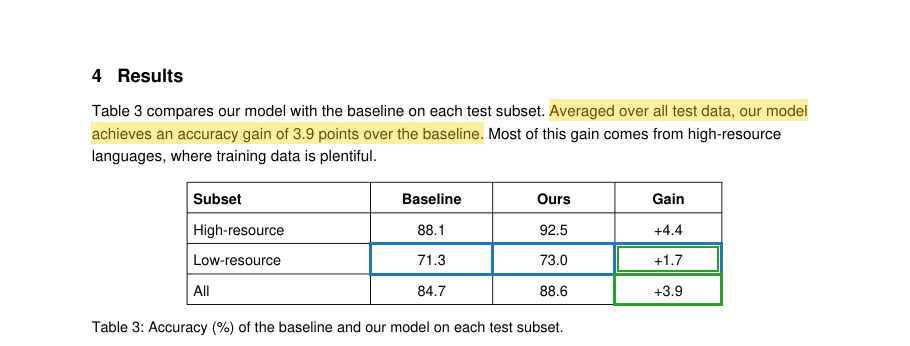

  claim 2  Table 3 cell Low-resource / Baseline PDF shows '71.3'   cited '71.3'
  claim 2  Table 3 cell Low-resource / Ours     PDF shows '73.0'   cited '73.0'
  claim 2  Table 3 cell Low-resource / Gain     PDF shows '+1.7'   cited '+1.7'
  claim 3  Table 3 cell Low-resource / Gain     PDF shows '+1.7'   cited '+1.7'
  claim 3  Table 3 cell All / Gain              PDF shows '+3.9'   cited '+3.9'
OK: every boxed cell shows its cited value in the PDF, and every quote is on the page


In [108]:
# 13A: the running example on the real PDF
proof_a = draw_proof(rx)
print("yellow = quoted sentence (N10a);", claim_legend(rx))
display(proof_a[0])

page2 = PAPER_PDF[1]
for b in rx["boxes"]:
    if "cell" not in b["what"]:
        continue
    claim = rx["claims"][b["claim"] - 1]
    cited = next(c["value"] for c in claim["cites"] if c["evidence"] == b["evidence"]
                 and f"{c['cell'][0]} / {c['cell'][1]}" in b["what"])
    shown = page2.get_textbox(pymupdf.Rect(b["bbox"])).strip()
    print(f"  claim {b['claim']}  {b['what']:36s} PDF shows {shown!r:8s} cited {cited!r}")
    assert shown == cited, f"{b['what']}: the box shows {shown!r}, not {cited!r}"

for claim in rx["claims"]:
    for cite in claim["cites"]:
        if "quote" in cite:
            assert page2.search_for(cite["quote"]), f"quote not on the page: {cite['quote'][:40]}"
print("OK: every boxed cell shows its cited value in the PDF, and every quote is on the page")

claim 1 = rgb(214, 39, 40), claim 2 = rgb(31, 119, 180)


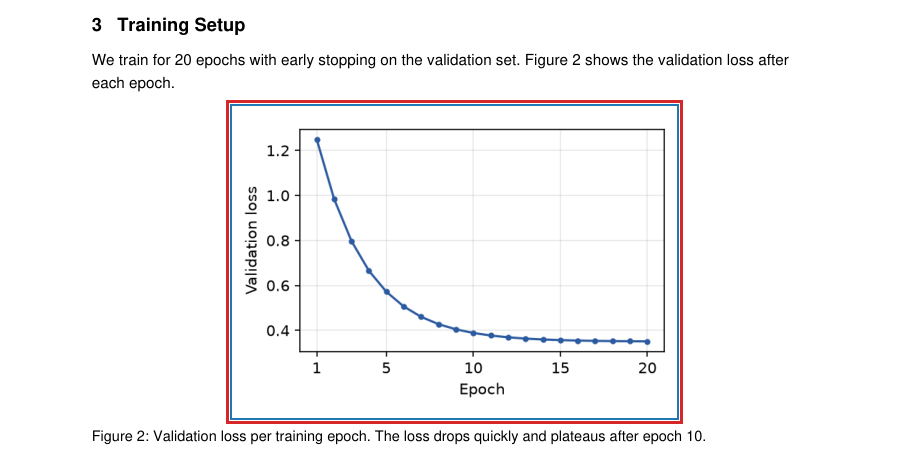

image on the page (PyMuPDF): (150.0, 323.4, 445.0, 520.0)
box from the patch map     : (148.8, 315.8, 446.2, 526.2)  -> IoU 0.93
OK: the box computed from the similarity map covers the chart PyMuPDF finds on the page


In [109]:
# 13B: the figure question on the real PDF
proof_b = draw_proof(rf)
print(claim_legend(rf))
display(proof_b[0])

image_box = tuple(PAPER_PDF[0].get_image_info()[0]["bbox"])
patch_box = next(b["bbox"] for b in rf["boxes"] if "patch map" in b["what"])
print(f"image on the page (PyMuPDF): {tuple(round(v, 1) for v in image_box)}")
print(f"box from the patch map     : {patch_box}  -> IoU {iou(patch_box, image_box):.2f}")
assert iou(patch_box, image_box) >= 0.85
print("OK: the box computed from the similarity map covers the chart PyMuPDF finds on the page")

In [110]:
# 13C: save both proofs side by side for the thesis
gap = 24
width = sum(im.width for im in proof_a + proof_b) + gap
height = max(im.height for im in proof_a + proof_b)
canvas = PILImage.new("RGB", (width, height), "white")
x = 0
for im in proof_a + proof_b:
    canvas.paste(im, (x, 0))
    x += im.width + gap

proof_path = PROJECT_ROOT / "paper" / "figures" / "fig_grounded_answer.png"
canvas.save(proof_path)
print("saved:", proof_path.relative_to(PROJECT_ROOT), f"({canvas.width}x{canvas.height} px)")

saved: paper/figures/fig_grounded_answer.png (1844x464 px)


## 14. A language-model planner (N5)

Everything so far used the rule-based planner. Here N5 gets a real language model:
**Qwen2.5-VL-7B**, served locally by **llama.cpp** (`llama-server`, PLAN.md step 5.13).

**Fairness.** The model sees exactly what the rule-based planner sees - the sub-goals,
the tools already tried, and what G1 said is missing - and nothing more. If it plans
better, the only difference is that it reads meaning, not keywords.

**Fixed answer shape.** llama.cpp forces the reply into a JSON schema: a one-sentence
reason, one tool from `MODALITIES`, and a search query. The model cannot invent a tool.

**The model proposes, the rules decide.** `propose_action` is stage 1; N5's rules are
stage 2 and apply to both planners: an invalid tool or a repeated (sub-goal, tool) pair is
overruled. So the loop bounds of Section 11 hold whichever planner runs.

**Both machines.** The notebook only talks to `localhost:8080`; llama.cpp decides how to
use the GPU, so the same code runs on the Arc and on the 3070. When no server is running,
the cells below skip, and the fallback is tested instead.

In [111]:
# LLM planner settings. PLANNER_MODE ("rules" or "llm") is set next to N5, in Section 6.
LLM_URL   = "http://localhost:8080/v1"      # llama.cpp llama-server
LLM_MODEL = "qwen2.5-vl-7b"                 # informational: the server answers with what it loaded

In [112]:
def llm_ready() -> bool:
    # True if a llama.cpp server answers at LLM_URL.
    try:
        with urllib.request.urlopen(f"{LLM_URL}/models", timeout=3) as reply:
            return reply.status == 200
    except OSError:                   # not running, refused, timed out
        return False

In [113]:
def llm_plan(state: AgentState) -> dict:
    # Ask the local model which tool to call next.
    # Returns {"tool", "query", "reason", "seconds"}. Raises OSError if the server
    # cannot be reached, ValueError on a reply that is not the required JSON --
    # the caller (propose_action) decides what to do.
    goals = "\n".join(f"{i}. [{g['modality']}] {g['text']}" for i, g in enumerate(state["sub_goals"], 1))
    tried = ", ".join(f"sub-goal {g + 1} with {t}" for g, t in state["tried"]) or "nothing yet"
    missing = (state.get("sufficiency") or {}).get("missing") or "nothing checked yet"
    system = ("You plan retrieval for questions about one scientific paper. Pick ONE tool: "
              "'text' searches paragraphs, 'table' searches tables, 'figure' searches charts. "
              "Do not repeat a tool already tried for the same sub-goal. Give a one-sentence "
              "reason, then the tool, then a short search query.")
    user = (f"Question: {state['question']}\nSub-goals:\n{goals}\n"
            f"Already tried: {tried}\nStill missing: {missing}")
    schema = {"type": "object",
              "properties": {"reason": {"type": "string"},
                             "tool":   {"type": "string", "enum": list(MODALITIES)},
                             "query":  {"type": "string"}},
              "required": ["reason", "tool", "query"]}
    body = {"model": LLM_MODEL, "temperature": 0, "seed": SEED,
            "messages": [{"role": "system", "content": system}, {"role": "user", "content": user}],
            "response_format": {"type": "json_schema", "json_schema": {"name": "plan", "schema": schema}}}
    request = urllib.request.Request(f"{LLM_URL}/chat/completions", data=json.dumps(body).encode("utf-8"),
                                     headers={"Content-Type": "application/json"})
    start = time.perf_counter()
    with urllib.request.urlopen(request, timeout=120) as reply:
        content = json.load(reply)["choices"][0]["message"]["content"]
    answer = json.loads(content)
    return {"tool": answer["tool"], "query": answer["query"], "reason": answer["reason"],
            "seconds": round(time.perf_counter() - start, 1)}

In [114]:
# 14A: the local model answers in the required shape
if not llm_ready():
    print(f"SKIPPED: no llama.cpp server at {LLM_URL}.")
    print("Start it (PLAN.md 5.13), e.g.:  llama-server -hf ggml-org/Qwen2.5-VL-7B-Instruct-GGUF -ngl 99 --port 8080")
else:
    probe = new_state(QUERY)
    TRACE = False
    probe.update(n1_query_intake(probe))
    probe.update(n2_query_encoder(probe))
    TRACE = True
    plan = llm_plan(probe)
    print(f"LLM chose : {plan['tool']}  <- {plan['query']!r}")
    print(f"reason    : {plan['reason']}")
    print(f"time      : {plan['seconds']} s")
    assert plan["tool"] in MODALITIES and plan["query"]
    print("OK: the model answers with a real tool, a query and a reason")

SKIPPED: no llama.cpp server at http://localhost:8080/v1.
Start it (PLAN.md 5.13), e.g.:  llama-server -hf ggml-org/Qwen2.5-VL-7B-Instruct-GGUF -ngl 99 --port 8080


In [115]:
# 14B: the LLM proposes, the rules decide
saved_mode, saved_url = PLANNER_MODE, LLM_URL
try:
    # (a) rules mode reproduces the Section 10 run exactly
    assert PLANNER_MODE == "rules"
    TRACE = False
    again = agent.invoke(new_state(QUERY))
    TRACE = True
    assert [(e.id, e.source) for e in again["evidence"]] == [(e.id, e.source) for e in rx["evidence"]]
    print("(a) rules mode: the running example retrieves exactly what it did in Section 10")

    # (b) LLM mode: the model plans every round, the rules still bound the loop
    if llm_ready():
        PLANNER_MODE = "llm"
        TRACE = False
        run14 = agent.invoke(new_state(QUERY))
        TRACE = True
        PLANNER_MODE = saved_mode
        print(f"(b) LLM planner: status={run14['status']}, rounds={run14['round']}, "
              f"planner={run14['action']['planner']!r}")
        print(f"    path: {run14['dag_trace']['path']}")
        assert run14["round"] <= MAX_ROUNDS
    else:
        print("(b) SKIPPED: no llama.cpp server")

    # (c) server unreachable: fall back to the rules, and say so
    PLANNER_MODE, LLM_URL = "llm", "http://localhost:9/v1"      # nothing listens here
    TRACE = False
    run14 = agent.invoke(new_state(QUERY))
    TRACE = True
    print(f"(c) unreachable server -> planner = {run14['action']['planner']!r}")
    assert run14["action"]["planner"] == "rules (LLM unavailable)"
    assert [(e.id, e.source) for e in run14["evidence"]] == [(e.id, e.source) for e in rx["evidence"]]
finally:
    PLANNER_MODE, LLM_URL, TRACE = saved_mode, saved_url, True

print()
print("OK: rules unchanged; an LLM plan passes through the same rules; "
      "a missing server falls back and is recorded")

(a) rules mode: the running example retrieves exactly what it did in Section 10
(b) SKIPPED: no llama.cpp server
(c) unreachable server -> planner = 'rules (LLM unavailable)'

OK: rules unchanged; an LLM plan passes through the same rules; a missing server falls back and is recorded


## 15. Where the Faithfulness Gate stops protecting

G2 compares a claim's **citations** with the buffer, and checks that every number in the
sentence is cited. It never reads what the sentence *says about* a number. That is its
strength - no judgement, no threshold - and also its boundary.

The table claim of the running example is written four ways:

| Case | What the generator writes | G2 |
|---|---|---|
| honest | low-resource gain **+1.7**, citing cell *Low-resource / Gain* | passes - and is true |
| fabricated | the baseline as **72.3**, citing a cell that says 71.3 | **rejects** |
| uncited | adds "61% of the high-resource gain", a number nobody cites | **rejects** |
| misattributed | low-resource gain **+4.4**, citing cell *High-resource / Gain* - which really is +4.4 | passes - but is **false** |

The last case is the finding: a real number, faithfully cited, attached to the wrong
subject. Every equality test passes, because the cell does say +4.4 - it is just the wrong
row. Catching it needs a check that reads the sentence's subject (an NLI model, or G2 as a
model call in the full system), and the evaluation's MAP metric should measure how often it
happens.

In [116]:
def run_with_style(style: str = "honest", lie_once: bool = False) -> AgentState:
    # Run the running example with the table claim written one of four ways.
    # Everything is put back afterwards, even after a crash.
    global TRACE, TABLE_CLAIM_STYLE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS
    saved = (TRACE, TABLE_CLAIM_STYLE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS)
    TRACE, TABLE_CLAIM_STYLE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = False, style, lie_once, False
    try:
        return agent.invoke(new_state(QUERY))
    finally:
        TRACE, TABLE_CLAIM_STYLE, HALLUCINATE_ONCE, HALLUCINATE_ALWAYS = saved

In [117]:
# The four cases. `claim` is the text whose presence among the published claims
# shows what reached the user.
R3_CASES = [
    {"case": "honest",        "style": "honest",        "lie_once": False,
     "claim": "+1.7 points versus +3.9 overall"},
    {"case": "fabricated",    "style": "honest",        "lie_once": True,
     "claim": "Baseline 72.3"},
    {"case": "uncited",       "style": "uncited",       "lie_once": False,
     "claim": "61% of the high-resource gain"},
    {"case": "misattributed", "style": "misattributed", "lie_once": False,
     "claim": "+4.4 points versus +3.9 overall"},
]
print(len(R3_CASES), "cases")

4 cases


In [118]:
# 15A: what G2 catches, and what reaches the user
r3_rows = []
for c in R3_CASES:
    out = run_with_style(c["style"], c["lie_once"])
    published = [x for x in out["claims"] if not x.get("rejected")]
    r3_rows.append({"case": c["case"],
                    "rejected": out["rewrite_count"] > 0,
                    "rewrites": out["rewrite_count"],
                    "reaches_user": any(c["claim"] in x["text"] for x in published),
                    "status": out["status"],
                    "out": out})

print(f"{'case':14s} {'G2':10s} {'rewrites':>8s}  {'reaches the user':18s} status")
print("-" * 80)
for r in r3_rows:
    print(f"{r['case']:14s} {'REJECTED' if r['rejected'] else 'passed':10s} {r['rewrites']:8d}  "
          f"{'yes' if r['reaches_user'] else 'no':18s} {r['status']}")

by = {r["case"]: r for r in r3_rows}
# the misattributed claim cites a real cell -- of the wrong row
mis = next(x for x in by["misattributed"]["out"]["claims"] if x.get("conclusion"))
print()
print("misattributed claim :", mis["text"])
print("its gain citation   :", mis["cites"][0])
assert mis["cites"][0]["cell"] == ("High-resource", "Gain"), "the swap did not cite the other row"
assert "low-resource" in mis["text"]

assert not by["honest"]["rejected"]        and by["honest"]["reaches_user"]
assert by["fabricated"]["rejected"]        and not by["fabricated"]["reaches_user"]
assert by["uncited"]["rejected"]           and not by["uncited"]["reaches_user"]
assert not by["misattributed"]["rejected"] and by["misattributed"]["reaches_user"]
assert TABLE_CLAIM_STYLE == "honest", "the style was not restored"
print()
print("OK: a misquote and an uncited number are caught; a real number on the wrong subject")
print("    passes every equality test and reaches the user -- G2's boundary")

case           G2         rewrites  reaches the user   status
--------------------------------------------------------------------------------
honest         passed            0  yes                ok
fabricated     REJECTED          1  no                 ok
uncited        REJECTED          2  no                 unsupported_claims_dropped
misattributed  passed            0  yes                ok

misattributed claim : So the gain does hold for the low-resource subset, and it is at least as large: +4.4 points versus +3.9 overall.
its gain citation   : {'evidence': 'E2', 'cell': ('High-resource', 'Gain'), 'value': '+4.4'}

OK: a misquote and an uncited number are caught; a real number on the wrong subject
    passes every equality test and reaches the user -- G2's boundary


## 16. From demo to full system

The graph above stays as it is. Making the system real means replacing node **bodies**,
one at a time, each against the tests in this notebook:

| Node | Stand-in here | Replaced by | PLAN.md |
|---|---|---|---|
| N3-N4 | `FAKE_PAPER`, keyword IDF index | PyMuPDF ingestion, ColQwen2 page index, SPECTER2 + FAISS text index over SPIQA papers | Days 2-3 |
| N6a / N6b / N6c | keyword, grid and caption search | SPECTER2 search / Table Transformer / ColQwen2 MaxSim | Days 3-4, 7 |
| N7 | `FakeTensor` crop | PyMuPDF 300 dpi re-render + ColQwen2 re-encode | Day 4 |
| N1, N2, N5, G1, N9, G2 | deterministic rules | Qwen2.5-VL-7B (4-bit, llama.cpp), prompted for JSON - Section 14 shows the pattern | Days 5-6 |
| N10b for figures | `fake_similarity_map` | colpali-engine similarity maps, same `patches_to_bbox` | Day 6 |

The evaluation then compares this graph with two variants of itself - **single-pass** (no
loops) and **text-only** (no visual tools) - on 150 SPIQA questions, scored on accuracy,
RF, MAP, AES and CGS. Section 11's cost table is the efficiency side of that comparison.